<a href="https://colab.research.google.com/github/Yvonneamg/Modelling-the-epidemiologic-evolution-of-Diabetes-Mellitus-Integrating-Physiological-Agent-models/blob/main/UpdatedHybridModeltodate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Load the required libraries**

In [18]:
# load the required libraries
!pip install jax jaxlib diffrax numpyro pyreadstat scipy matplotlib pandas
import scipy
import jax # For high performance numerical computing and automatic differentiation
import jax.numpy as jnp
import time
import scipy.stats
import jax.random as random
from jax import debug
from scipy import optimize
from scipy.stats import lognorm
from scipy.stats import multivariate_normal
from sklearn.metrics import roc_curve, auc
import pyreadstat
import pandas as pd # For data handling
import numpy as np # For data handling
from jax import jit, vmap
from jax.experimental.ode import odeint
from scipy.optimize import differential_evolution
from jax.scipy.special import logsumexp
import diffrax # For solving ODES
import math
from functools import partial
import matplotlib.pyplot as plt # For visualization
import matplotlib as mpl
from collections import defaultdict
import gc
import os
from datetime import datetime
import pickle
import numpyro # For probablistic modeling to be implemented later
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.optim import Adam
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer import SVI, Trace_ELBO, init_to_median
from tqdm import tqdm
import optax
print("Setup complete!")

Setup complete!


#**Global Figure Saver**

In [19]:
# ============================================================================
# GLOBAL FIGURE SAVER
# ============================================================================

# Folder to store plots
PLOT_OUTPUT_DIR = "diabetes_updated"
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)

def save_figure(fig, name_prefix):
    """
    Save a matplotlib figure safely with timestamp.
    """

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"{name_prefix}_{timestamp}.png"

    filepath = os.path.join(PLOT_OUTPUT_DIR, filename)

    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    #plt.close(fig)

    print(f"Saved: {filename}")
    #return filepath

# **Reproduce De Gaetano Physiological Model.**

[5.0e+00 1.0e+03 3.5e+01 1.0e-03 1.0e-02 1.8e+01]
Simulation completed
Base:7.065633535385132
Base:0.0057985782623291016
Base:0.006093025207519531
Base:0.008014917373657227
Saved: physiological_model_validation_20260423_074340.png


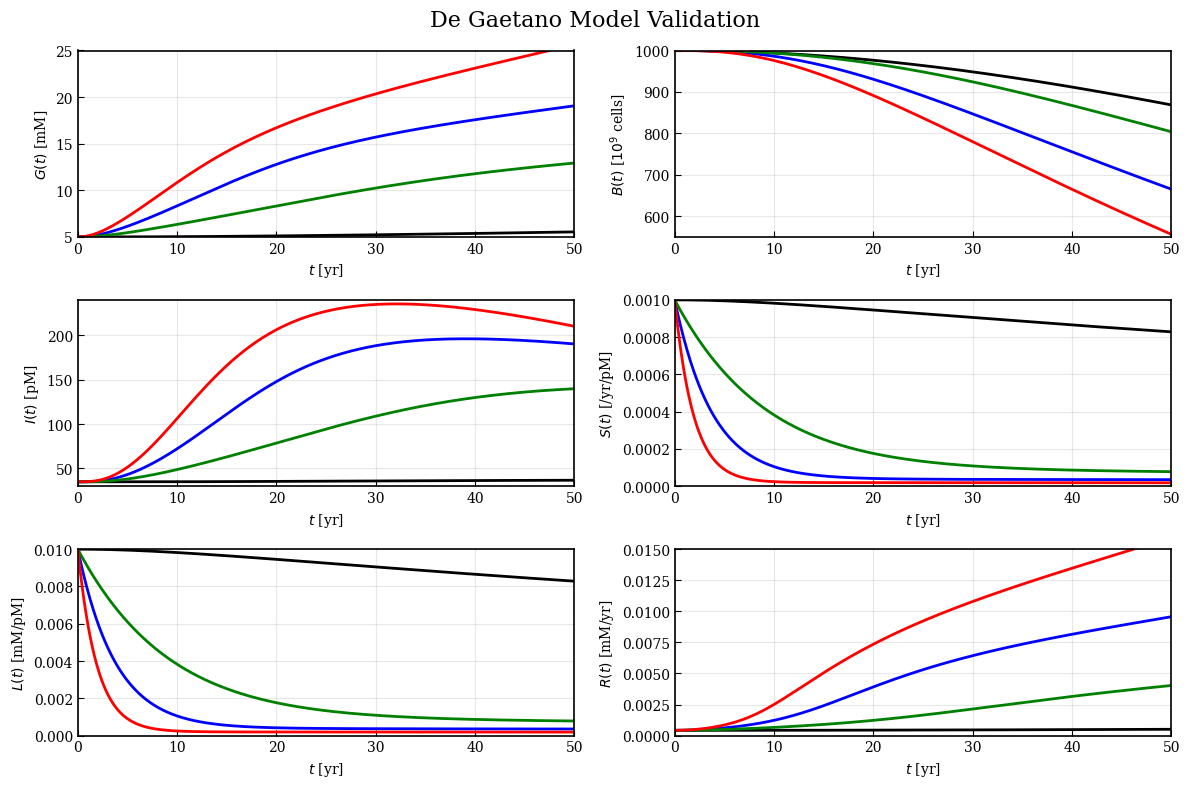

In [20]:
# =============================================================================
# PART 1: DE GAETANO PHYSIOLOGICAL MODEL
# =============================================================================

# Base parameters (Table 2)
params_base = {
    't0': 0, 'tend': 50, 't_delta': 0.1,
    'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0,
    'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144,
    'k_max_G': 1.00948, 'G_0': 5.0,
    'lambda_BA': 0.005, 'k_OB_G': 0.005, 'k_B': 25.0, 'B0_N': 1000.0,
    'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0,
    'k_S': 0.0001, 'k_SY': 1e-09, 'k_OS': 0.1, 'k_OSF': 1e-05, 'k_OSA': 0.0005, 'S_0': 0.001,
    'k_L': 0.001, 'k_LY': 2e-09, 'k_OL': 0.1, 'k_OLF': 1e-05, 'k_OLA': 0.0005, 'L_0': 0.01,
    's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144,
    'F': 0.0, 'Y': 0.0, 'A0': 18.0
}


# Case parameters (Table 3)
params_cases = {}

for case in ['Black', 'Blue', 'Green', 'Red']:
    params_cases[case] = params_base.copy()

params_cases['Black'].update({
    'k_OB_G': 0.005, 'k_OS': 0.1, 'k_OL': 0.1,
    'k_B': 25.0, 'k_S': 0.0001, 'k_L': 0.001,
    'F': 0.0, 'k_OSF': 1e-05, 'k_OLF': 1e-5
})

params_cases['Blue'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0005, 'k_OLF': 0.0005
})

params_cases['Green'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.0002, 'k_OLF': 0.0002
})

params_cases['Red'].update({
    'k_OB_G': 0.001, 'k_OS': 0.01, 'k_OL': 0.01,
    'k_B': 5.0, 'k_S': 1e-05, 'k_L': 0.0001,
    'F': 500.0, 'k_OSF': 0.001, 'k_OLF': 0.001
})

# Initial conditions (y0: [G, B, I, S, L, A]; B0=1000 Mc from Table 2)
A0=params_base['A0']
y0_base = jnp.array([params_base['G_0'], params_base['B_0'], params_base['I_0'], params_base['S_0'], params_base['L_0'],params_base['A0'] ])
print(y0_base)

# ODE RHS

def ode_rhs(t, y, params): #function ode_rhs that calculates how fast each body variable (like glucose or insulin) is changing at a specific moment t. It's the "rules" for how the system evolves, based on current states and settings.
    G, B, I, S, L, A = y #the array of state variables at time t
    F = params['F']
    Y = params['Y']

    # Eq 8: Renal R(G(t))
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    dGdt = params['k_max_G'] * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    dBdt = params['k_B'] * (jnp.exp(-params['lambda_BA'] * (A - A0))) - (params['k_OB_G'] * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    dIdt = -(params['k_OI'] * I) + ((B / params['B0_N']) * params['k_max_I'] * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    dSdt = params['k_S'] - (params['k_OS'] * S) + (params['k_SY'] * Y) - (params['k_OSF'] * F * S) - (params['k_OSA'] * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    dLdt = params['k_L'] - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (params['k_OLF'] * F * L) - (params['k_OLA'] * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    dAdt = 1.0

    return jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

def ode_rhs_scan(y, t_span, opt_params , params, dt, y0):
    G, B, I, S, L, A = y #the array of state variables at time t
    G0, B0, I0, S0, L0, A0 = y0 #the array of state variables at time t
    lambda_BA,k_OB_G,k_OI,k_OSF,k_OSA,k_OLF,k_OLA = opt_params

    F = params['F']
    Y = params['Y']

    #Eq 8: Renal R(G(t))
    discriminant = (4 * params['rho_GR'] * G0) + ((G0 - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R0 = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G0 - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2) # Calculates a helper number for the kidney function—it's part of smoothing out when kidneys start removing sugar (avoids sharp jumps).
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR'])) # Computes the kidney sugar removal rate (R) using a square root formula. It's like a gentle ramp-up: low when glucose is normal, higher when it's elevated.

    #k_max_G = (jnp.exp(L0 * I0 * G0)) * (S0 * I0 * G0 + R0)
    #k_max_I = (k_OI * I0) / ((G0 ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + G0 ** params['gamma_IG']))
    #k_B = k_OB_G * G0 * B0
    #k_L = params['k_OL'] * L0 + k_OLF*F*L0
    #k_S = params['k_OS'] * S0 + k_OSF*F*S0

    #k_max_G = (jnp.exp(params['L0_N'] * params['I0_N'] * params['G0_N'])) * (params['S0_N'] * params['I0_N'] * params['G0_N'] + params['R0_N'])
    #k_max_I = (params['k_OI'] * params['I0_N']) / ((params['G0_N'] ** params['gamma_IG']) / (params['G_I50'] ** params['gamma_IG'] + params['G0_N'] ** params['gamma_IG']))
    #k_B = params['k_OB_G'] *  params['G0_N'] *  params['B0_N']
    #k_L = params['k_OL'] *  params['L0_N']
    #k_S = params['k_OS'] *  params['S0_N']

    k_max_G = params['k_max_G']
    k_max_I = params['k_max_I']
    k_B = params['k_B']
    k_L = params['k_L']
    k_S = params['k_S']

    # Eq1: dG/dt: Describes glucose dynamics. It's max liver sugar production (slowed by insulin and liver sensitivity) minus sugar used by body tissues minus kidney removal.
    dGdt = k_max_G * (jnp.exp(-(L * I * G))) - (S * I * G) - R

    # Eq2: dB/dt : Describes beta cell mass dynamics. It's a base growth rate (that fades with age) minus damage from high sugar.
    dBdt = k_B * (jnp.exp(-lambda_BA * (A - A0))) - (k_OB_G * G * B)

    # Eq3: dI/dt (Hill function): Describes insulin dynamics
    hill = G**params['gamma_IG'] / ((params['G_I50']**params['gamma_IG']) + (G**params['gamma_IG'])) # shows how insulin secretion ramps up with higher glucose—starts slow, then accelerates, like a sensitivity switch.
    dIdt = -(k_OI * I) + ((B / B0) * k_max_I * hill) # it's minus natural breakdown plus production from beta cells (scaled by their number and the glucose trigger)

    # Eq4: dS/dt : Peripheral insulin sensitivity: Base recovery minus natural fade plus exercise boost minus penalty from extra food minus age-related drop
    dSdt = k_S - (params['k_OS'] * S) + (params['k_SY'] * Y) - (k_OSF * F * S) - (k_OSA * (A - A0) * S)

    # Eq5: dL/dt: Liver insulin sensitivity dynamics: Base recovery minus fade plus exercise minus food penalty minus age drop.
    dLdt = k_L - (params['k_OL'] * L )+ (params['k_LY'] * Y )- (k_OLF * F * L) - (k_OLA * (A - A0) * L)

    # Eq6: dA/dt: Age: Age just increases steadily by 1 year per year
    dAdt = 1.0
    next_state = jax.nn.softplus((y + dt*jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt]))*100.0)/100.0
    return next_state, next_state

# -----------------------------------------------------------------------------
# Euler solver
# -----------------------------------------------------------------------------
@jit
def solve_ode(params, t_span, y0):
    """Solve ODE with Diffrax"""
    def rhs(t, y, args): return ode_rhs(t, y, args) #A wrapper that calls the change-calculating function above.
    term = diffrax.ODETerm(rhs)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(term, solver, t0=t_span[0], t1=t_span[-1], dt0=0.1, y0=y0,args=params, saveat=diffrax.SaveAt(ts=t_span)) # Runs the solver: starts at time 0, goes to the end time, steps by 0.1 units, uses initial values y0, passes settings (params), and saves results at specific times in t_span.
    return sol.ys

t_span = jnp.linspace(0, 50, 1000)


print("Simulation completed")
#print("Solution shape:", sol.shape)



# PHYSIOLOGICAL MODEL VALIDATION PLOT

# R computation
def compute_R(G, params):
    discriminant = (4 * params['rho_GR'] * G) + ((G - params['G_R'] - params['rho_GR'])**2)
    R = (params['s_GR'] / 2) * (jnp.sqrt(discriminant) + (G - params['G_R'] - params['rho_GR']))
    return R

# Time span


# Figure and colors
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
fig.suptitle("De Gaetano Model Validation", fontsize=16, y=0.98)

colors = {
    'Black': 'black',
    'Blue': 'blue',
    'Green': 'green',
    'Red': 'red'
}

for case, color in colors.items():

    # Get parameters
    params = params_cases[case]

    y0 = jnp.array([
        params['G_0'],
        params['B_0'],
        params['I_0'],
        params['S_0'],
        params['L_0'],
        params['A0']
    ])

    # Solve model
    start_t = time.time()
    sol = solve_ode(params, t_span, y0)
    print("Base:"+str(time.time()-start_t))

    sol = np.array(sol)

    # Create age axis
    age = np.linspace(0, 50, len(sol))

    # Plot states
    axes[0,0].plot(age, sol[:,0], color=color, linewidth=2, label=case)
    axes[0,1].plot(age, sol[:,1], color=color, linewidth=2, label=case)
    axes[1,0].plot(age, sol[:,2], color=color, linewidth=2, label=case)
    axes[1,1].plot(age, sol[:,3], color=color, linewidth=2, label=case)
    axes[2,0].plot(age, sol[:,4], color=color, linewidth=2, label=case)

     # Compute R from G
    R_values = compute_R(sol[:,0], params)
    axes[2,1].plot(age, R_values, color=color, linewidth=2.0)  # R(t)


# =============================================================================
# AXIS LABELS
# =============================================================================

axes[0,0].set_ylabel(r"$G(t)$ [mM]")
axes[0,0].set_xlabel(r"$t$ [yr]")
axes[0,0].set_xlim(0,50)
axes[0,0].set_ylim(5,25)

axes[0,1].set_ylabel(r"$B(t)$ [$10^9$ cells]")
axes[0,1].set_xlabel(r"$t$ [yr]")
axes[0,1].set_xlim(0,50)
axes[0,1].set_ylim(550,1000)

axes[1,0].set_ylabel(r"$I(t)$ [pM]")
axes[1,0].set_xlabel(r"$t$ [yr]")
axes[1,0].set_xlim(0,50)
axes[1,0].set_ylim(30,240)

axes[1,1].set_ylabel(r"$S(t)$ [/yr/pM]")
axes[1,1].set_xlabel(r"$t$ [yr]")
axes[1,1].set_xlim(0,50)
axes[1,1].set_ylim(0.0000,0.0010)

axes[2,0].set_ylabel(r"$L(t)$ [mM/pM]")
axes[2,0].set_xlabel(r"$t$ [yr]")
axes[2,0].set_xlim(0,50)
axes[2,0].set_ylim(0.000,0.010)

axes[2,1].set_ylabel(r"$R(t)$ [mM/yr]")
axes[2,1].set_xlabel(r"$t$ [yr]")
axes[2,1].set_xlim(0,50)
axes[2,1].set_ylim(0.000,0.015)


# Grid
for ax in axes.flat:
    ax.grid(True, alpha=0.3)

# Layout
plt.tight_layout()

# Save figure using global saver
save_figure(fig, "physiological_model_validation")

# Show plot
plt.show()

##**Renal Glucose Elimination**

Saved: Renal glucose elimination_20260423_074345.png


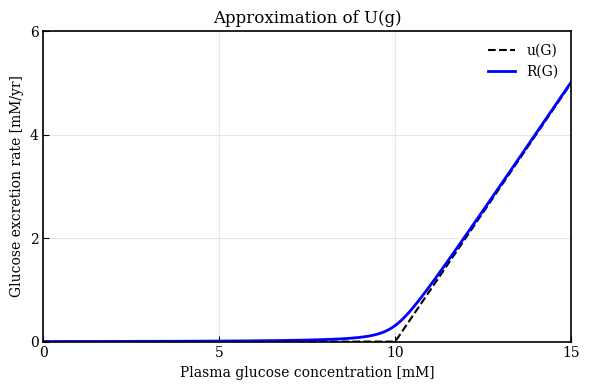

In [21]:
# The term  𝑅(𝐺(𝑡)) represents the average decrement of glucose concentration due to renal glucose elimination and to possible therapy with SGLT-2 inhibitors.
# Construction of equation 8
s_GR = 1.0  # mM/yr per mM (scale for linear elimination)
rho_GR = 0.01 # mM (smoothing factor)
G_R = 10.0  # mM (renal threshold)

# Glucose range (x-axis: 0 to 15 mM)
G = np.linspace(0, 15, 1000)

# Exact step function u(G) from Eq. (9)
u_G = np.where(G < G_R, 0, (s_GR * (G - G_R)))  # Piecewise: 0 below threshold, linear above

# Smooth approximation R(G) from Eq. (8)
discriminant = (4 * rho_GR * G) + ((G - G_R - rho_GR)**2)
R_G = (s_GR / 2) * (np.sqrt(discriminant) + (G - G_R - rho_GR))

# Plot dashed for u(G), solid blue for R(G)
plt.figure(figsize=(6, 4))
plt.plot(G, u_G, 'k--', linewidth=1.5, label='u(G)')  # Dashed black
plt.plot(G, R_G, 'b-', linewidth=2, label='R(G)')     # Solid blue
plt.xlabel('Plasma glucose concentration [mM]')
plt.ylabel('Glucose excretion rate [mM/yr]')
plt.xlim(0, 15)
plt.ylim(0, 6)
plt.xticks(np.arange(0, 16, 5))  # x-axis ticks: 0, 5, 10, 15
plt.yticks(np.arange(0, 7, 2))   # y-axis ticks: 0, 2, 4, 6
plt.grid(True, alpha=0.3)  # Light grid for readability
plt.legend()
plt.title('Approximation of U(g)')
plt.tight_layout()
save_figure(fig,"Renal glucose elimination")
plt.show()

# The smooth R(G) effectively approximates the biological renal threshold mechanism (where kidneys excrete excess glucose only above ~10 mM), no elimination in normoglycemia (G<10 mM), linear spillover in hyperglycemia

## **Simulation of impact of dietary changes**

Saved: Impact of dietary scenarios on model trajectories_20260423_074405.png


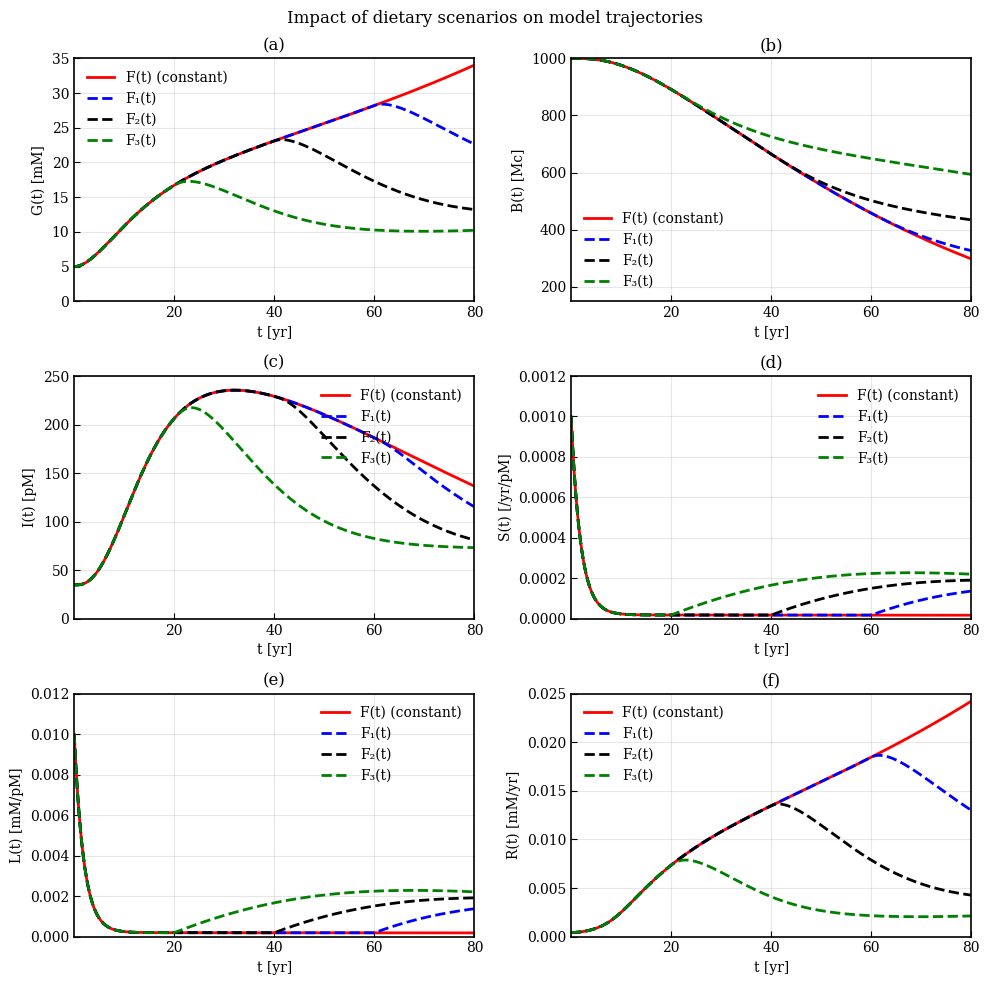

Red: Late-life avg G = 32.77 mM
F1: Late-life avg G = 24.08 mM
F2: Late-life avg G = 13.65 mM
F3: Late-life avg G = 10.15 mM


In [22]:
# Excess food intake effect

# Plot styling
mpl.rcParams.update({
    "text.usetex": False,    # LaTeX for all text
    "font.family": "serif",  # Serif font for paper style
    "axes.linewidth": 1.2,   # Thicker border lines
    "xtick.direction": "in", # Inward ticks
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,  # No legend border
    "axes.facecolor": "white", # Clean white background
})

# Extend to t=80 yr (finer grid for smooth curves)
t_span = jnp.linspace(0, 80, 2000)
A0 = 18.0  # Starting age

# PARAMETERS
# Update "Red" params to include A0
params_red = params_cases['Red'].copy()
params_red['A0'] = A0
params_red['F'] = 500.0  # Excess level

# Initial conditions for Red case
y0_red = jnp.array([
    params_red['G_0'],    # G0
    params_red['B_0'],    # B0
    params_red['I_0'],    # I0
    params_red['S_0'],    # S0
    params_red['L_0'],    # L0
    A0                    # A0
])

# Scenarios dict: F_type as int (0=constant/inf, 1=60yr, 2=40yr, 3=20yr drop)
scenarios = {
    'Red': {'params': params_red, 'F_type': 0, 'color': 'red', 'style': '-', 'label': 'F(t) (constant)'},
    'F1': {'params': params_red, 'F_type': 1, 'color': 'blue', 'style': '--', 'label': 'F₁(t)'},
    'F2': {'params': params_red, 'F_type': 2, 'color': 'black', 'style': '--', 'label': 'F₂(t)'},
    'F3': {'params': params_red, 'F_type': 3, 'color': 'green', 'style': '--', 'label': 'F₃(t)'}
}

# ODE SYSTEM
# Updated ODE RHS: Inline thresh computation with JAX conditionals
def ode_rhs_timevar(t, y, args):
    params = args['params']
    F_type = args['F_type']
    G, B, I, S, L, A = y

    # Time-varying F: Chain jnp.where for branches
    # F_type 0: always 500 (thresh=inf)
    # F_type 1: 500 if t<60 else 0
    # F_type 2: 500 if t<40 else 0
    # F_type 3: 500 if t<20 else 0
    F = jnp.where(F_type == 0, params['F'],  # Constant
                  jnp.where(F_type == 1, jnp.where(t < 60.0, params['F'], 0.0),
                            jnp.where(F_type == 2, jnp.where(t < 40.0, params['F'], 0.0),
                                      jnp.where(F_type == 3, jnp.where(t < 20.0, params['F'], 0.0), 0.0))))  # Fallback 0
    Y = params['Y']  # Still 0


    # Renal R(G(t)) from Eq. 8
    discriminant = 4 * params['rho_GR'] * G + (G - params['G_R'] - params['rho_GR'])**2
    R = (params['s_GR'] / 2) * (jnp.sqrt(jnp.maximum(discriminant, 0.0)) + (G - params['G_R'] - params['rho_GR']))

    # Eq. 1: Glucose
    dGdt = params['k_max_G'] * jnp.exp(-L * I * G) - S * I * G - R

    # Eq. 2: Beta-cell mass
    dBdt = params['k_B'] * jnp.exp(-params['lambda_BA'] * (A - params['A0'])) - params['k_OB_G'] * G * B

    # Eq. 3: Insulin (Hill)
    hill = G**params['gamma_IG'] / (params['G_I50']**params['gamma_IG'] + G**params['gamma_IG'])
    dIdt = -params['k_OI'] * I + (B / params['B0_N']) * params['k_max_I'] * hill

    # Eq. 4: Peripheral sensitivity S
    dSdt = params['k_S'] - params['k_OS'] * S + params['k_SY'] * Y - params['k_OSF'] * F * S - params['k_OSA'] * (A - params['A0']) * S

    # Eq. 5: Central sensitivity L
    dLdt = params['k_L'] - params['k_OL'] * L + params['k_LY'] * Y - params['k_OLF'] * F * L - params['k_OLA'] * (A - params['A0']) * L

    # Eq. 6: Age
    dAdt = 1.0

    return jnp.array([dGdt, dBdt, dIdt, dSdt, dLdt, dAdt])

# Solve
def solve_ode_timevar(args, t_span, y0):
    # Direct lambda: Passes full args to ode_rhs_timevar
    vector_field = lambda t, y, _: ode_rhs_timevar(t, y, args)

    term = diffrax.ODETerm(vector_field)
    solver = diffrax.Euler()
    sol = diffrax.diffeqsolve(
        term, solver,
        t0=t_span[0], t1=t_span[-1],
        dt0=0.1, y0=y0,
        saveat=diffrax.SaveAt(ts=t_span)
    )
    return sol.ys  # Shape: (n_times, 6)


# Simulate all scenarios
solutions = {}
for name, info in scenarios.items():
    args = {'params': info['params'], 'F_type': info['F_type']}
    sol = solve_ode_timevar(args, t_span, y0_red)
    solutions[name] = sol

# Plot Fig. 5: 3x2 subplots
fig, axs = plt.subplots(3, 2, figsize=(10, 10))
age = t_span # Plot vs. age [yr]

for name, info in scenarios.items():
    sol = solutions[name]
    color, style, label = info['color'], info['style'], info['label']


    # print(f"{name} I min max: {sol[:,2].min()} {sol[:,2].max()}")  # Added to diagnose max I

    axs[0,0].plot(age, sol[:,0], color=color, linestyle=style, linewidth=2, label=label)

    axs[0,1].plot(age, sol[:,1], color=color, linestyle=style, linewidth=2, label=label)

    axs[1,0].plot(age, sol[:,2], color=color, linestyle=style, linewidth=2, label=label)

    axs[1,1].plot(age, sol[:,3], color=color, linestyle=style, linewidth=2, label=label)

    axs[2,0].plot(age, sol[:,4], color=color, linestyle=style, linewidth=2, label=label)

    R_vals = vmap(lambda g: compute_R(g, info['params']))(sol[:,0])
    axs[2,1].plot(age, R_vals, color=color, linestyle=style, linewidth=2, label=label)

# Formatting
axs[0,0].set_title('(a)')
axs[0,0].set_ylabel(r"G(t) [mM]")
axs[0,0].set_xlim(0, 80)
axs[0,0].set_ylim(0, 35)
axs[0,0].legend()

axs[0,1].set_title('(b)')
axs[0,1].set_ylabel(r"B(t) [Mc]")
axs[0,1].set_xlim(0, 80)
axs[0,1].set_ylim(150, 1000)
axs[0,1].legend()

axs[1,0].set_title('(c)')
axs[1,0].set_ylabel(r"I(t) [pM]")
axs[1,0].set_xlim(0, 80)
axs[1,0].set_ylim(0, 250)
axs[1,0].legend(loc='upper right')

axs[1,1].set_title('(d)')
axs[1,1].set_ylabel(r"S(t) [/yr/pM]")
axs[1,1].set_xlim(0, 80)
axs[1,1].set_ylim(0, 0.0012)
axs[1,1].legend()

axs[2,0].set_title('(e)')
axs[2,0].set_ylabel(r"L(t) [mM/pM]")
axs[2,0].set_xlim(0, 80)
axs[2,0].set_ylim(0, 0.012)
axs[2,0].legend()

axs[2,1].set_title('(f)')
axs[2,1].set_ylabel(r"R(t) [mM/yr]")
axs[2,1].set_xlim(0, 80)
axs[2,1].set_ylim(0, 0.025)
axs[2,1].legend()

for ax in axs.flat:
    ax.set_xlabel('t [yr]')
    ax.grid(True, alpha=0.3)
    ax.set_xticks([20, 40, 60, 80])  # Only show these tick marks

plt.suptitle("Impact of dietary scenarios on model trajectories")
plt.tight_layout()
save_figure(fig,"Impact of dietary scenarios on model trajectories")
plt.show()


# Print late-life averages
for name in scenarios:
    late_G = jnp.mean(solutions[name][-200:, 0])  # Avg G over last ~2 yr
    print(f"{name}: Late-life avg G = {late_G:.2f} mM")


# **NHANES data Processing**

In [23]:
# ============================================================================
# LOAD NHANES DATA FILES FROM GOOGLE DRIVE
# ============================================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File paths
file_path = "/content/drive/MyDrive/Colab Notebooks/PAXRAW_C.xpt"
demo_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/DEMO_C.xpt"
gluc_path = "/content/drive/MyDrive/Colab Notebooks/2003-2004/L10AM_C.xpt"
DR1TOT_C = "/content/drive/MyDrive/Colab Notebooks/Datasets/DR1TOT_C.xpt"

# Load datasets
demo_df = pd.read_sas(demo_path)
gluc_df = pd.read_sas(gluc_path)
dr1tot_df = pd.read_sas(DR1TOT_C)

# Quick verification
print("Datasets loaded successfully\n")


print("DEMO_C shape:", demo_df.shape)
print("GLUC_C shape:", gluc_df.shape)
print("DR1TOT_C shape:", dr1tot_df.shape)
#print("Glucose stats:", gluc_df["LBDGLUSI"].describe())
#print("Insulin stats:", gluc_df["LBDINSI"].describe())

cache_file = "nhanes_cached.pkl"
if os.path.exists(cache_file):

    print("Loading NHANES data from cache...")

    with open(cache_file, "rb") as f:
        data = pickle.load(f)

    print("Loaded cached dataset.")
    print("Rows:", len(data))

else:

    print("No cache found. Running full NHANES processing...")

    # Load demographic data
    demo, _ = pyreadstat.read_xport(
        demo_path,
        usecols=["SEQN", "WTMEC2YR", "RIDAGEYR", "RIAGENDR"]
    )

    # Load glucose / insulin data
    gluc, _ = pyreadstat.read_xport(gluc_path)

    # Load accelerometer data
    accel, _ = pyreadstat.read_xport(
        file_path,
        usecols=["SEQN", "PAXINTEN", "PAXSTAT", "PAXDAY"]
    )

    # Load dietary intake
    diet = pd.read_sas(DR1TOT_C)
    diet = diet[["SEQN", "DR1TKCAL"]]
    diet = diet[diet["DR1TKCAL"] > 0]


    # Merge datasets

    data = demo.copy()

    data = data.merge(gluc, on="SEQN", how="left")
    data = data.merge(diet, on="SEQN", how="left")

    # Process accelerometer data

    accel = accel[accel["PAXSTAT"] == 1]

    accel["intensity"] = pd.cut(
        accel["PAXINTEN"],
        bins=[-1, 99, 759, 2019, np.inf],
        labels=["sedentary", "light", "moderate", "vigorous"]
    )

    daily = (
        accel.groupby(["SEQN", "PAXDAY", "intensity"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    intensity_cols = ["sedentary", "light", "moderate", "vigorous"]

    for col in intensity_cols:
        if col not in daily.columns:
            daily[col] = 0

    daily["total_minutes"] = daily[intensity_cols].sum(axis=1)

    daily = daily[daily["total_minutes"] >= 600]

    person_activity = daily.groupby("SEQN")[intensity_cols + ["total_minutes"]].mean()

    person_activity["mvpa_minutes"] = (
        person_activity["moderate"] + person_activity["vigorous"]
    )

    data = data.merge(person_activity[["mvpa_minutes"]], on="SEQN", how="left")

    # Rename columns

    data = data.rename(
        columns={
            "RIDAGEYR": "age",
            "RIAGENDR": "gender",
            "WTMEC2YR": "weight",
            "DR1TKCAL": "calories",
            "LBDGLUSI": "glucose",
            "LBDINSI": "insulin"
        }
    )


    # Keep adults only

    data = data[data["age"] >= 18].copy()

    # ---------------------------------------------------------------------
    # Remove rows with missing required variables
    # ---------------------------------------------------------------------
    required_columns = ["age", "weight", "mvpa_minutes", "calories","glucose","insulin"]

    data = data.dropna(subset=required_columns)
    print("Datasets loaded successfully")

    # SAVE CACHE
    print("Saving processed dataset...")

    with open(cache_file, "wb") as f:
        pickle.dump(data, f)

    print("Cache saved:", cache_file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Datasets loaded successfully

DEMO_C shape: (10122, 44)
GLUC_C shape: (3356, 7)
DR1TOT_C shape: (9643, 160)
Loading NHANES data from cache...
Loaded cached dataset.
Rows: 2084


In [24]:
# Cleaned data and summary

# Remove invalid weights, calories, mvpa_minutes
data = data[data["weight"] > 0]

data = data[(data["calories"] > 500) & (data["calories"] < 6000)] # ensure reasonable ranges

data = data[(data["mvpa_minutes"] >= 0) & (data["mvpa_minutes"] < 600)] # ensure reasonable ranges

print("Remaining individuals:", len(data))

print("Age range:", data["age"].min(), "-", data["age"].max())

print("Mean MVPA:", data["mvpa_minutes"].mean())

print("Mean calories:", data["calories"].mean())

data.head()


Remaining individuals: 2052
Age range: 18.0 - 85.0
Mean MVPA: 81.24647266313933
Mean calories: 2184.5375243664716


,SEQN,gender,age,weight,WTSAF2YR,LBXGLU,glucose,LBXCPSI,LBXIN,insulin,calories,mvpa_minutes
0,21005.0,1.0,19.0,5824.782465,14084.10,87.6,4.863,0.591,11.26,67.56,2984.0,102.428571
15,21020.0,2.0,55.0,29102.083555,65607.89,88.1,4.890,0.717,9.05,54.30,2575.0,30.571429
20,21025.0,2.0,18.0,13772.570375,33084.63,85.6,4.752,0.447,3.22,19.32,990.0,111.714286
24,21029.0,1.0,40.0,100099.630952,211685.72,92.9,5.157,0.987,11.02,66.12,4907.0,91.428571
28,21033.0,2.0,57.0,25488.344933,60329.07,96.3,5.346,0.919,11.52,69.12,1042.0,109.714286


##**Step 6: Fitting behavioral models**

Saved: age_trends_20260423_074417.png


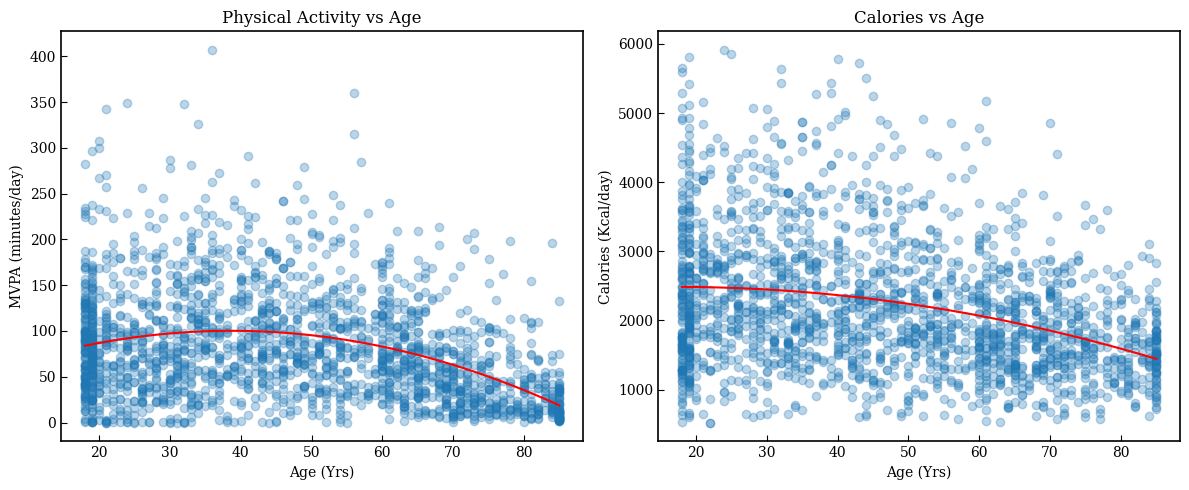

In [25]:
# AGE TRENDS: PHYSICAL ACTIVITY AND CALORIES VS AGE FOR THE WHOLE DATASET

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MVPA vs Age

axes[0].scatter(data['age'], data['mvpa_minutes'], alpha=0.3)

mvpa_coeffs = np.polyfit(data['age'], data['mvpa_minutes'], 2)
mvpa_poly = np.poly1d(mvpa_coeffs)

x = np.linspace(data['age'].min(), data['age'].max(), 200)

axes[0].plot(x, mvpa_poly(x), color='red')

axes[0].set_title("Physical Activity vs Age")
axes[0].set_xlabel("Age (Yrs)")
axes[0].set_ylabel("MVPA (minutes/day)")

# Calories vs Age
axes[1].scatter(data['age'], data['calories'], alpha=0.3)

cal_coeffs = np.polyfit(data['age'], data['calories'], 2)
cal_poly = np.poly1d(cal_coeffs)

axes[1].plot(x, cal_poly(x), color='red')

axes[1].set_title("Calories vs Age")
axes[1].set_xlabel("Age (Yrs)")
axes[1].set_ylabel("Calories (Kcal/day)")

# Layout + Save
plt.tight_layout()
save_figure(fig, "age_trends")
plt.show()

Fitting behavioral models...

Behavior models fitted
MVPA polynomial coefficients: [-7.61531146e-04  6.24084275e-02  3.13605642e+00]
Calories polynomial coefficients: [-2.25155146e-01  7.64940956e+00  2.42041782e+03]
MVPA residual std: 0.928798228369071
Calories residual std: 904.1731316710991
length of data: 2052
Shape check:
F: (1000,) Y: (1000,)

Basic stats:
F -> min: 0.0 max: 2704.6123 mean: 328.5059
Y -> min: 1.6960418 max: 1510.4814 mean: 98.31364

Constant mode check:
Unique Y: [0.]
Unique F: [0.]

Calories below baseline → F should be 0:
Max F: 0.0

Determinism check:
F identical: False
Y identical: False

MVPA positivity check:
Any negative? False

Trend vs noisy output:
Mean of trend: 4.121200937781981
Mean of sampled: 4.1190157


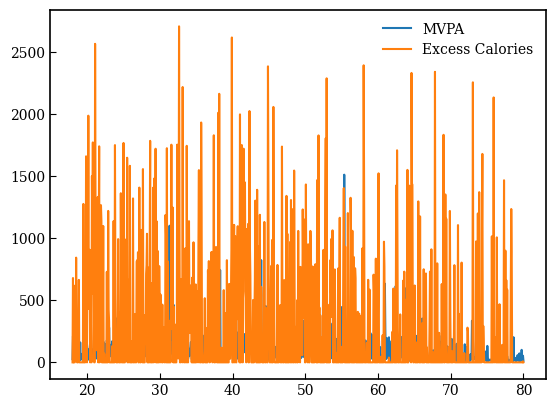

In [26]:
# =============================================================================
# FIT AGE-DEPENDENT BEHAVIORAL MODELS
# =============================================================================

print("Fitting behavioral models...")

# Fit quadratic polynomial trends

mvpa_coeffs = np.polyfit(data["age"],np.log(data["mvpa_minutes"] + 1),2) # Logtransform since mvpa is highly skewed, many small values few large values

calorie_coeffs = np.polyfit(data["age"],data["calories"],2)

# Create polynomial models

mvpa_poly = np.poly1d(mvpa_coeffs)
calorie_poly = np.poly1d(calorie_coeffs)


# Compute residual variability

mvpa_residuals = np.log(data["mvpa_minutes"] + 1) - mvpa_poly(data["age"])

calorie_residuals = data["calories"] - calorie_poly(data["age"])


mvpa_sigma = np.std(mvpa_residuals)

calorie_sigma = np.std(calorie_residuals)


print("\nBehavior models fitted")

print("MVPA polynomial coefficients:", mvpa_coeffs)

print("Calories polynomial coefficients:", calorie_coeffs)

print("MVPA residual std:", mvpa_sigma)

print("Calories residual std:", calorie_sigma)
print("length of data:",len(data))


# Store results for later use
behavior_models = {
    "mvpa_poly": mvpa_poly,
    "calorie_poly": calorie_poly,
    "mvpa_sigma": mvpa_sigma,
    "calorie_sigma": calorie_sigma
}


def generate_behavior_trajectories(age_grid, mvpa0, cal0, behavior_mode, key):
    """
    Generates F(t), Y(t) trajectories

    behavior_mode:
        - "constant": no behavior → F = 0, Y = 0
        - "dynamic": sampled from fitted polynomials
    """

    if behavior_mode == "constant":
        # Explicitly no behavior
        F_traj = jnp.zeros_like(age_grid)
        Y_traj = jnp.zeros_like(age_grid)

    elif behavior_mode == "dynamic":
        # --- mean trends ---
        mvpa_mean = behavior_models["mvpa_poly"](age_grid)
        mvpa_mean = mvpa_mean - mvpa_mean[0] + jnp.log(mvpa0 + 1)

        cal_mean = behavior_models["calorie_poly"](age_grid)
        cal_mean = cal_mean - cal_mean[0] + cal0

        # --- randomness ---
        key1, key2 = jax.random.split(key)

        mvpa_traj = jnp.exp(
            mvpa_mean +
            behavior_models["mvpa_sigma"] *
            jax.random.normal(key1, shape=age_grid.shape)
        )

        cal_traj = (
            cal_mean +
            behavior_models["calorie_sigma"] *
            jax.random.normal(key2, shape=age_grid.shape)
        )

        # --- convert to model inputs ---
        baseline = 2000.0
        F_traj = jnp.maximum(cal_traj - baseline, 0.0)
        Y_traj = mvpa_traj

    else:
        raise ValueError("behavior_mode must be 'constant' or 'dynamic'")

    return F_traj, Y_traj

key = jax.random.PRNGKey(42)
# split keys for different calls
age_grid = jnp.linspace(18, 80, 1000)  # 10 points only

key, subkey = jax.random.split(key)
F, Y = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey)

print("Shape check:")
print("F:", F.shape, "Y:", Y.shape)

print("\nBasic stats:")
print("F -> min:", F.min(), "max:", F.max(), "mean:", F.mean())
print("Y -> min:", Y.min(), "max:", Y.max(), "mean:", Y.mean())


# Constant mode does NOT need randomness
F_const, Y_const = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "constant", key)

print("\nConstant mode check:")
print("Unique Y:", jnp.unique(Y_const))
print("Unique F:", jnp.unique(F_const))


F_low, _ = generate_behavior_trajectories(age_grid, 50.0, 1800.0, "constant", key)
print("\nCalories below baseline → F should be 0:")
print("Max F:", F_low.max())


#USE DIFFERENT KEYS

key, subkey1 = jax.random.split(key)
key, subkey2 = jax.random.split(key)

F1, Y1 = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey1)
F2, Y2 = generate_behavior_trajectories(age_grid, 50.0, 2200.0, "dynamic", subkey2)

print("\nDeterminism check:")
print("F identical:", jnp.allclose(F1, F2))
print("Y identical:", jnp.allclose(Y1, Y2))


print("\nMVPA positivity check:")
print("Any negative?", (Y < 0).any())


mvpa_mean = behavior_models["mvpa_poly"](age_grid)

print("\nTrend vs noisy output:")
print("Mean of trend:", mvpa_mean.mean())
print("Mean of sampled:", jnp.log(Y).mean())


plt.plot(age_grid, Y, label="MVPA")
plt.plot(age_grid, F, label="Excess Calories")
plt.legend()
plt.show()

Saved: residuals_20260423_074420.png


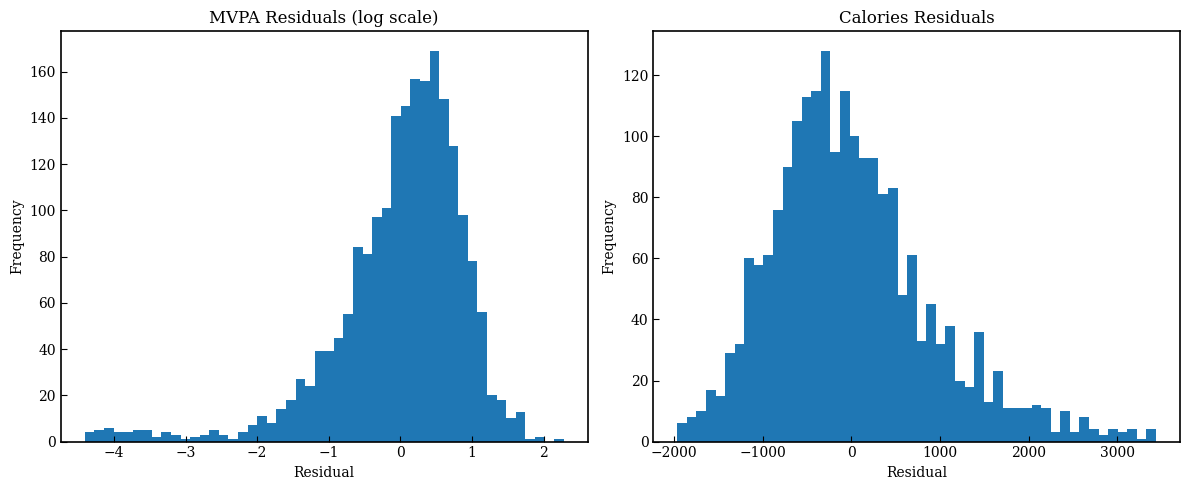

In [27]:
# RESIDUAL DISTRIBUTIONS

fig, axes = plt.subplots(1,2, figsize=(12,5))

# MVPA residuals
axes[0].hist(mvpa_residuals, bins=50)
axes[0].set_title("MVPA Residuals (log scale)")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frequency")

# Calories residuals
axes[1].hist(calorie_residuals, bins=50)
axes[1].set_title("Calories Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
save_figure(fig, "residuals")
plt.show()

Saved: simulated_MVPA_Calorie_percentiles_20260423_074421.png


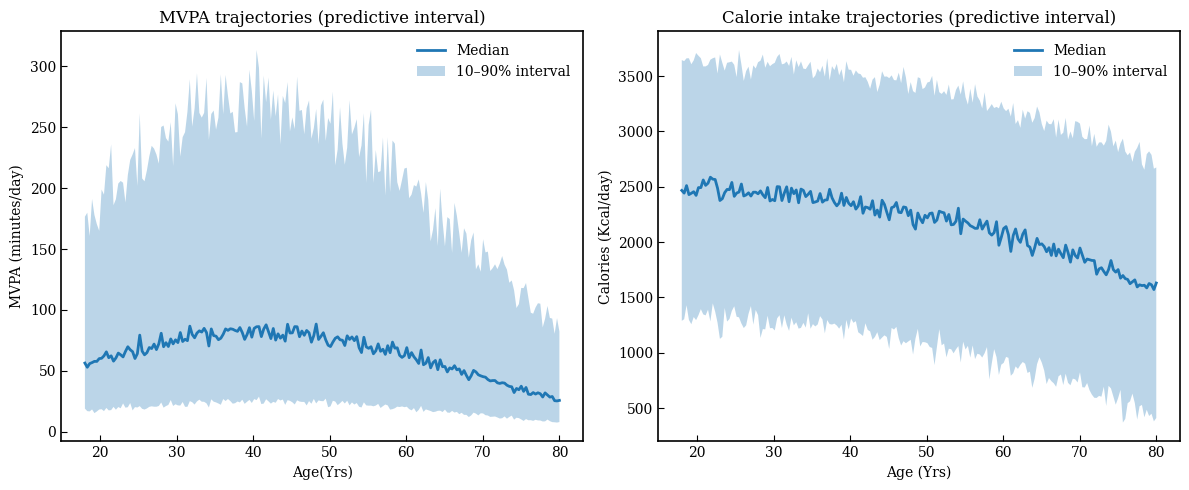

In [28]:
# ============================================
# SIMULATED BEHAVIORAL TRAJECTORIES
# ============================================

ages = np.linspace(18, 80, 200)
n_sim = 500

mvpa_all = []
cal_all = []

for _ in range(n_sim):

    # --- MVPA (log-space noise, consistent with model) ---
    mvpa_mean = mvpa_poly(ages)                     # log-space mean
    mvpa_noise = np.random.normal(0, mvpa_sigma, size=len(ages))

    mvpa_sim = np.exp(mvpa_mean + mvpa_noise)       # back to original scale

    # --- Calories (additive noise) ---
    cal_mean = calorie_poly(ages)
    cal_noise = np.random.normal(0, calorie_sigma, size=len(ages))

    cal_sim = cal_mean + cal_noise

    mvpa_all.append(mvpa_sim)
    cal_all.append(cal_sim)

# Convert to arrays
mvpa_all = np.array(mvpa_all)
cal_all = np.array(cal_all)

# PERCENTILES

mvpa_p10 = np.percentile(mvpa_all, 10, axis=0)
mvpa_p50 = np.percentile(mvpa_all, 50, axis=0)
mvpa_p90 = np.percentile(mvpa_all, 90, axis=0)

cal_p10 = np.percentile(cal_all, 10, axis=0)
cal_p50 = np.percentile(cal_all, 50, axis=0)
cal_p90 = np.percentile(cal_all, 90, axis=0)

# PLOTTING

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- MVPA ----
axes[0].plot(ages, mvpa_p50, label="Median", linewidth=2)
axes[0].fill_between(ages, mvpa_p10, mvpa_p90, alpha=0.3, label="10–90% interval")

axes[0].set_title("MVPA trajectories (predictive interval)")
axes[0].set_xlabel("Age(Yrs)")
axes[0].set_ylabel("MVPA (minutes/day)")
axes[0].legend()

# ---- Calories ----
axes[1].plot(ages, cal_p50, label="Median", linewidth=2)
axes[1].fill_between(ages, cal_p10, cal_p90, alpha=0.3, label="10–90% interval")

axes[1].set_title("Calorie intake trajectories (predictive interval)")
axes[1].set_xlabel("Age (Yrs)")
axes[1].set_ylabel("Calories (Kcal/day)")
axes[1].legend()

plt.tight_layout()

# Save (optional)
save_figure(fig, "simulated_MVPA_Calorie_percentiles")

plt.show()

## **Step 7: Build the initial conditions**

In [29]:
# =============================================================================
# BUILD INITIAL CONDITIONS FROM YOUNG NHANES INDIVIDUALS
# =============================================================================

n = 100   # number of individuals to sample

required_cols = [
    "age",
    "glucose",
    "insulin",
    "mvpa_minutes",
    "calories"
]

missing = [c for c in required_cols if c not in data.columns]

if missing:
    raise ValueError("Required NHANES columns missing: " + str(missing))


# Select young adults
young = data[(data["age"] >= 18) & (data["age"] <= 22)].copy()

if len(young) == 0:
    raise ValueError("No individuals aged 18–22 found")


# Remove rows with missing values
young = young.dropna(subset=required_cols)


if len(young) < n:
    raise ValueError(
        f"Requested {n} individuals but only {len(young)} have complete data"
    )


# Randomly sample individuals
sample = young.sample(n, random_state=42)

N_samples=100


# EMPIRICAL INITIALIZATION
empirical_subset = sample.sample(N_samples, random_state=42)

empirical_G0 = jnp.array(empirical_subset["glucose"].values)
empirical_I0 = jnp.array(empirical_subset["insulin"].values)
empirical_age = jnp.array(empirical_subset["age"].values)
empirical_mvpa = jnp.array(empirical_subset["mvpa_minutes"].values)
empirical_calories = jnp.array(empirical_subset["calories"].values)


# Build initial state vectors
initials = []

for _, row in sample.iterrows():

    A0 = float(row["age"])
    G0= float(row["glucose"])
    I0= float(row["insulin"])
    MVPA0 = float(row["mvpa_minutes"])
    CAL0 = float(row["calories"])


    initials.append([
        G0,     # Glucose
        I0,     # Insulin
        A0,     # Age
        MVPA0,  # Behavior (extra)
        CAL0    # Behavior (extra)
    ])


initials = np.array(initials)
initials_all=initials

print("\nYoung calibration cohort created")
print("Individuals:", len(initials))
print("Mean age:", np.mean(initials[:,2]))
print("Mean MVPA:", np.mean(initials[:,3]))
print("Mean calories:", np.mean(initials[:,4]))
print("Initials:",initials.shape)



Young calibration cohort created
Individuals: 100
Mean age: 19.13
Mean MVPA: 86.29857142857144
Mean calories: 2199.18
Initials: (100, 5)


In [30]:
# =============================================================================
# BUILD AGE-BINNED NHANES STATISTICS
# =============================================================================
data_filtered = data[(data["age"] >= 20) & (data["age"] <= 80)].copy()
bins = [20,30,40,50,60,70,80]
age_mid = np.array([25,35,45,55,65,75])
data_filtered["age_bin"] = pd.cut( data_filtered["age"], bins=bins, labels=age_mid )

grouped = data_filtered.groupby("age_bin", observed=True)

results = {
    "age_mid": age_mid,

    "G_p10": grouped["glucose"].quantile(0.1).values,
    "G_p50": grouped["glucose"].quantile(0.5).values,
    "G_p90": grouped["glucose"].quantile(0.9).values,

    "I_p10": grouped["insulin"].quantile(0.1).values,
    "I_p50": grouped["insulin"].quantile(0.5).values,
    "I_p90": grouped["insulin"].quantile(0.9).values,

    "mvpa_p10": grouped["mvpa_minutes"].quantile(0.1).values,
    "mvpa_p50": grouped["mvpa_minutes"].quantile(0.5).values,
    "mvpa_p90": grouped["mvpa_minutes"].quantile(0.9).values,

    "cal_p10": grouped["calories"].quantile(0.1).values,
    "cal_p50": grouped["calories"].quantile(0.5).values,
    "cal_p90": grouped["calories"].quantile(0.9).values,
}

print("Age-binned statistics built")
age_midpoints = results["age_mid"]

Age-binned statistics built


Saved: age_binned_percentile_plots_20260423_074422.png


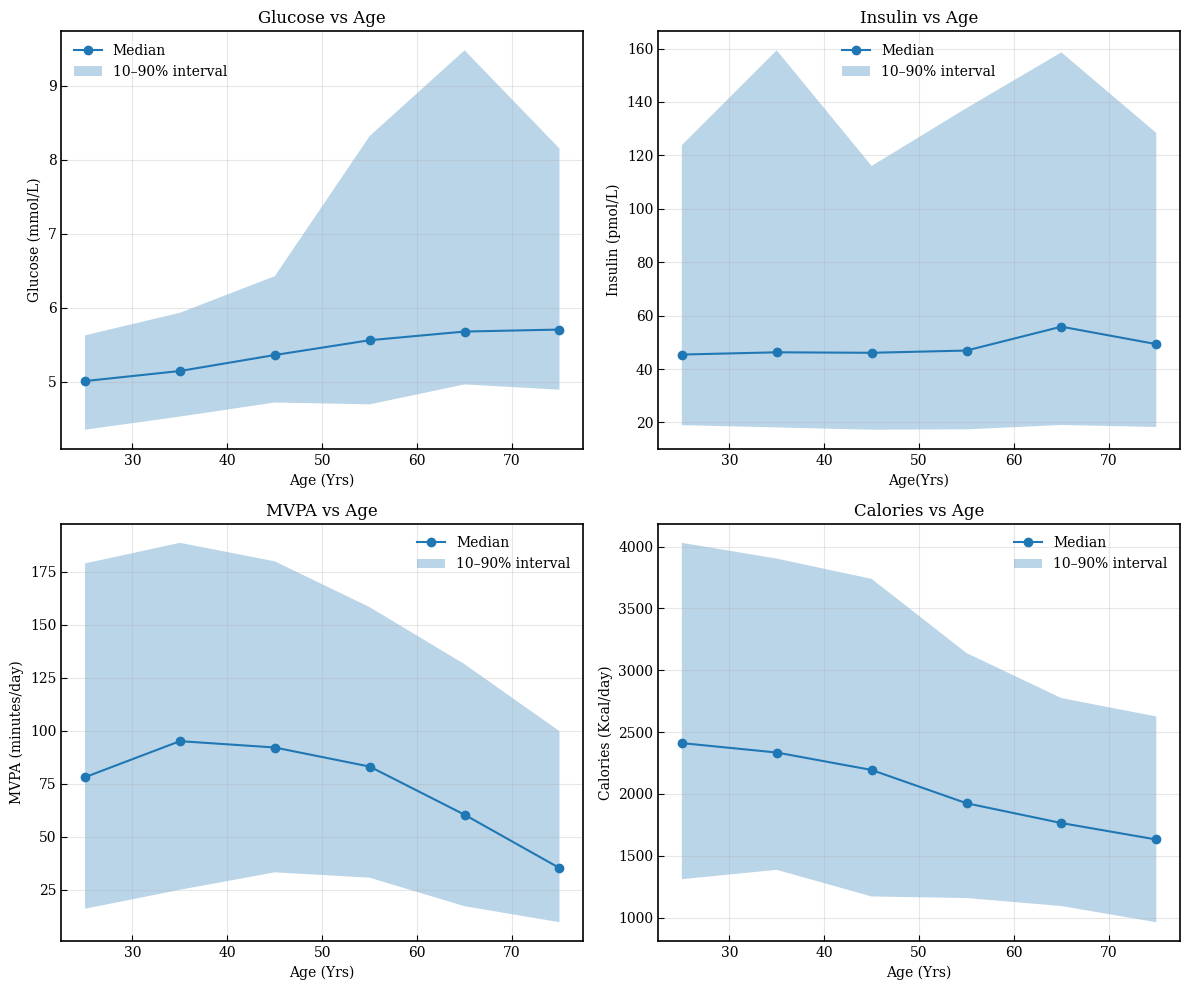

In [31]:
# =============================================================================
# AGE-BINNED PERCENTILE PLOTS
# =============================================================================

age = results["age_mid"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# -------------------------
# Glucose
# -------------------------
axes[0,0].plot(age, results["G_p50"], marker='o', label="Median")
axes[0,0].fill_between(
    age,
    results["G_p10"],
    results["G_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[0,0].set_title("Glucose vs Age")
axes[0,0].set_xlabel("Age (Yrs)")
axes[0,0].set_ylabel("Glucose (mmol/L)")
axes[0,0].grid(True, alpha=0.3)
axes[0,0].legend()

# -------------------------
# Insulin
# -------------------------
axes[0,1].plot(age, results["I_p50"], marker='o', label="Median")
axes[0,1].fill_between(
    age,
    results["I_p10"],
    results["I_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[0,1].set_title("Insulin vs Age")
axes[0,1].set_xlabel("Age(Yrs)")
axes[0,1].set_ylabel("Insulin (pmol/L)")
axes[0,1].grid(True, alpha=0.3)
axes[0,1].legend()

# -------------------------
# MVPA
# -------------------------
axes[1,0].plot(age, results["mvpa_p50"], marker='o', label="Median")
axes[1,0].fill_between(
    age,
    results["mvpa_p10"],
    results["mvpa_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[1,0].set_title("MVPA vs Age")
axes[1,0].set_xlabel("Age (Yrs)")
axes[1,0].set_ylabel("MVPA (minutes/day)")
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# -------------------------
# Calories
# -------------------------
axes[1,1].plot(age, results["cal_p50"], marker='o', label="Median")
axes[1,1].fill_between(
    age,
    results["cal_p10"],
    results["cal_p90"],
    alpha=0.3,
    label="10–90% interval"
)
axes[1,1].set_title("Calories vs Age")
axes[1,1].set_xlabel("Age (Yrs)")
axes[1,1].set_ylabel("Calories (Kcal/day)")
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()

# Layout
plt.tight_layout()
save_figure(fig, "age_binned_percentile_plots")
plt.show()

## **Fit a multivariate normal distribution to the (insulin, glucose) in the 18-22 age cohort**

In [32]:
# FIT MULTIVARIATE NORMAL (GLUCOSE, INSULIN)
glucose = young["glucose"].values
insulin = young["insulin"].values
print("Min insulin:", insulin.min())

#log_insulin = np.log(np.clip(insulin, 1e-6, None))
log_insulin = np.log(insulin)

data_pairs = np.column_stack((glucose, log_insulin))


# Fit Gaussian
mean = np.mean(data_pairs, axis=0)
cov = np.cov(data_pairs.T)

print(data_pairs.shape)
print("Fitted mean:", mean)
print("Fitted covariance:", cov)

Min insulin: 4.26
(333, 2)
Fitted mean: [5.0239009  3.92838834]
Fitted covariance: [[0.64853198 0.17334269]
 [0.17334269 0.68761548]]


Saved: Actual histogram of glucose insulin pairs_20260423_074425.png


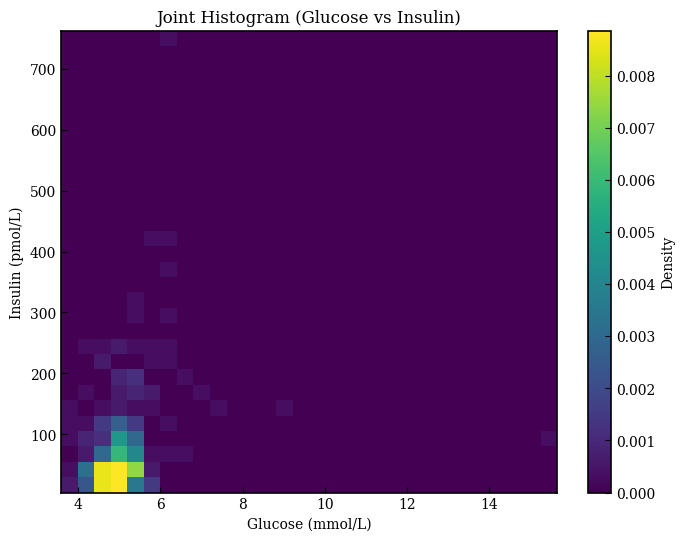

In [33]:
# ACTUAL HISTOGRAM OF (GLUCOSE, INSULIN) PAIRS
plt.figure(figsize=(8, 6))

plt.hist2d(glucose, insulin, bins=30, density=True)

plt.xlabel("Glucose (mmol/L)")
plt.ylabel("Insulin (pmol/L)")
plt.title("Joint Histogram (Glucose vs Insulin)")

#plt.yscale("log")  # Add log scale

plt.colorbar(label="Density")
fig = plt.gcf()
save_figure(fig, "Actual histogram of glucose insulin pairs")
plt.show()

Any NaNs in Z? False
Any infs in Z? False
Saved: Fitted Histogram and scatter gaussian distribution_20260423_074426.png


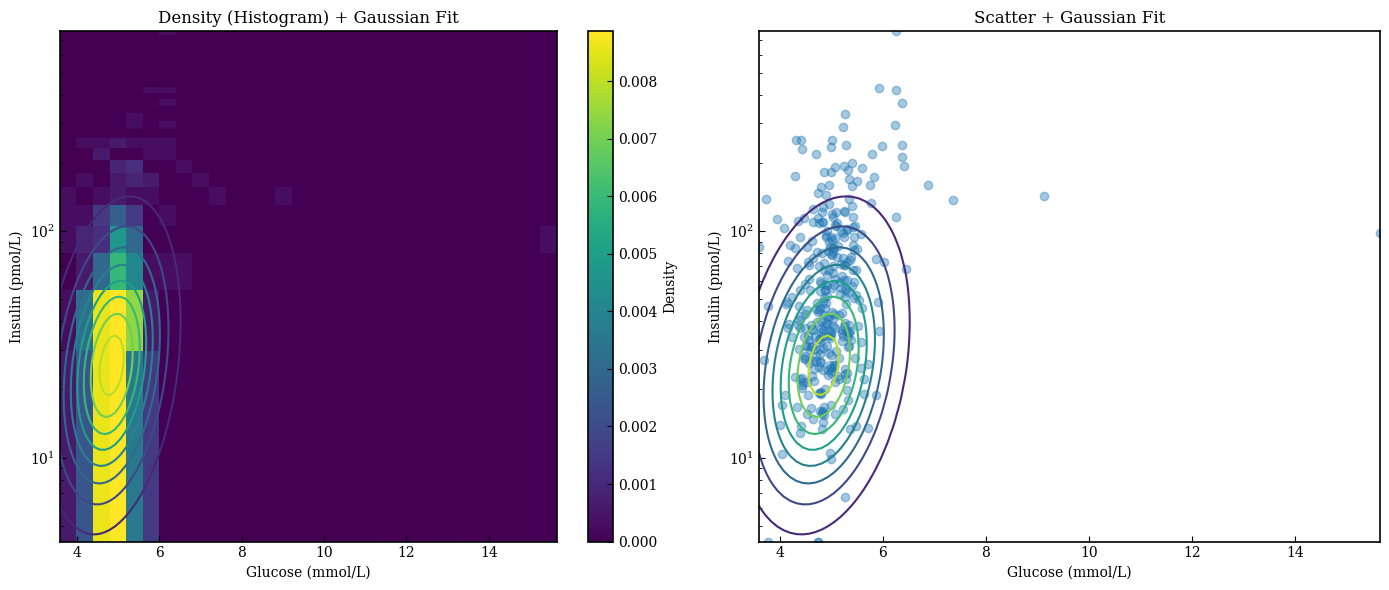

In [34]:
# Plots of fitted distribution

# Grid
x = np.linspace(glucose.min(), glucose.max(), 100)
y = np.logspace(np.log10(insulin.min()), np.log10(insulin.max()), 100)

X, Y = np.meshgrid(x, y)

# Log-transform insulin
#log_Y = np.log(np.clip(Y, 1e-6, None))
log_Y = np.log(Y)
pos = np.dstack((X, log_Y))

# Gaussian in (G, log I)
rv = multivariate_normal(mean, cov)
Z_log = rv.pdf(pos)

# Jacobian
Z = Z_log / Y
print("Any NaNs in Z?", np.isnan(Z).any())
print("Any infs in Z?", np.isinf(Z).any())
#Z = np.nan_to_num(Z, nan=0.0, posinf=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram
hist = axes[0].hist2d(glucose, insulin, bins=30, density=True)

axes[0].contour(X, Y, Z, levels=10)
axes[0].set_yscale("log")

axes[0].set_xlabel("Glucose (mmol/L)")
axes[0].set_ylabel("Insulin (pmol/L)")
axes[0].set_title("Density (Histogram) + Gaussian Fit")

fig.colorbar(hist[3], ax=axes[0], label="Density")

# Scatter
axes[1].scatter(glucose, insulin, alpha=0.4)
axes[1].contour(X, Y, Z, levels=10)
axes[1].set_yscale("log")

axes[1].set_xlabel("Glucose (mmol/L)")
axes[1].set_ylabel("Insulin (pmol/L)")
axes[1].set_title("Scatter + Gaussian Fit")

plt.tight_layout()
save_figure(fig, "Fitted Histogram and scatter gaussian distribution")
plt.show()

## **Defining Parameter Distributions over the model parameters**



  

In [35]:
print(params_cases["Red"])

# PARAM DISTRIBUTIONS
theta_keys = [
  "lambda_BA",
    "k_OB_G",
    "k_OI",
    "k_OSF",
    "k_OSA",
    "k_OLF",
    "k_OLA"
]

param_dist = {
    "lambda_BA": {"mu": params_cases["Red"]["lambda_BA"], "sigma": 0.003},
    "k_OB_G":    {"mu": params_cases["Red"]["k_OB_G"], "sigma": 0.003},
    "k_OI":      {"mu": params_cases["Red"]["k_OI"],  "sigma": 0.02},
    "k_OSF":     {"mu": params_cases["Red"]["k_OSF"], "sigma": 0.003},
    "k_OSA":     {"mu": params_cases["Red"]["k_OSA"], "sigma": 0.003},
    "k_OLF":     {"mu": params_cases["Red"]["k_OLF"], "sigma": 0.003},
    "k_OLA":     {"mu": params_cases["Red"]["k_OLA"], "sigma": 0.003}
}

print("Initial guesses distribution")
print(param_dist)

# MULTIVARIATE INIT DISTRIBUTION
# Convert already computed mean/cov to jax arrays
mean_jax = jnp.array(mean)     # shape (2,)
cov_jax = jnp.array(cov)       # shape (2,2)

# SAMPLING FUNCTION
def sample_parameters(key, param_dist, init_mean, init_cov, N):

    # SPLIT MAIN KEYS
    key_params, key_init, key_age, key_behavior = random.split(key, 4)

    # SAMPLE AGE
    ages = random.choice(
        key_age,
        jnp.array(young["age"]),
        shape=(N,)
    )

    # SAMPLE BEHAVIOR
    mvpa_mean = behavior_models["mvpa_poly"](ages)

    key_mvpa, key_cal = random.split(key_behavior)

    mvpa = jnp.exp(
        mvpa_mean +
        behavior_models["mvpa_sigma"] *
        random.normal(key_mvpa, shape=(N,))
    )

    calories = (
        behavior_models["calorie_poly"](ages) +
        behavior_models["calorie_sigma"] *
        random.normal(key_cal, shape=(N,))
    )

    # SPLIT KEYS FOR LOOP
    keys = random.split(key_params, N)

    samples = []
    matrix_samples = []

    for i in range(N):
        subkey = keys[i]
        sample = {}

        # Split key for params + multivariate
        subkeys = random.split(subkey, len(param_dist) + 1)

        vector_samples = []

        # PARAMS
        for j, (name, dist) in enumerate(param_dist.items()):
            val = random.normal(subkeys[j]) * dist["sigma"] + dist["mu"]
            sample[name] = val
            vector_samples.append(val)

        # MULTIVARIATE (G0, I0)
        gi_sample = random.multivariate_normal(
            subkeys[-1],
            mean=init_mean,
            cov=init_cov
        )

        sample["G0"] = gi_sample[0]
        sample["I0"] = jnp.exp(gi_sample[1])

        vector_samples.append(sample["G0"])
        vector_samples.append(sample["I0"])

        # ADD AGE + BEHAVIOR
        sample["age"] = ages[i]
        sample["mvpa"] = mvpa[i]
        sample["calories"] = calories[i]

        vector_samples.append(sample["age"])
        vector_samples.append(sample["mvpa"])
        vector_samples.append(sample["calories"])

        samples.append(sample)
        matrix_samples.append(jnp.array(vector_samples))

    return samples, jnp.stack(matrix_samples)

key = random.PRNGKey(0)

N = 100

samples, vectorized_samples = sample_parameters(
    key,
    param_dist,
    mean_jax,
    cov_jax,
    N
)

print(len(samples))
print(samples[0])
print(vectorized_samples.shape)
print(vectorized_samples[:,-2])
print(vectorized_samples[:,-1])

{'t0': 0, 'tend': 50, 't_delta': 0.1, 'G0_N': 5.0, 'B_0': 1000.0, 'I0_N': 35.0, 'S0_N': 0.001, 'L0_N': 0.01, 'R0': 0.000422144, 'k_max_G': 1.00948, 'G_0': 5.0, 'lambda_BA': 0.005, 'k_OB_G': 0.001, 'k_B': 5.0, 'B0_N': 1000.0, 'k_OI': 0.5, 'gamma_IG': 2.0, 'G_I50': 20.0, 'k_max_I': 297.5, 'I_0': 35.0, 'k_S': 1e-05, 'k_SY': 1e-09, 'k_OS': 0.01, 'k_OSF': 0.001, 'k_OSA': 0.0005, 'S_0': 0.001, 'k_L': 0.0001, 'k_LY': 2e-09, 'k_OL': 0.01, 'k_OLF': 0.001, 'k_OLA': 0.0005, 'L_0': 0.01, 's_GR': 0.001, 'rho_GR': 0.5, 'G_R': 10.0, 'R0_N': 0.000422144, 'F': 500.0, 'Y': 0.0, 'A0': 18.0}
Initial guesses distribution
{'lambda_BA': {'mu': 0.005, 'sigma': 0.003}, 'k_OB_G': {'mu': 0.001, 'sigma': 0.003}, 'k_OI': {'mu': 0.5, 'sigma': 0.02}, 'k_OSF': {'mu': 0.001, 'sigma': 0.003}, 'k_OSA': {'mu': 0.0005, 'sigma': 0.003}, 'k_OLF': {'mu': 0.001, 'sigma': 0.003}, 'k_OLA': {'mu': 0.0005, 'sigma': 0.003}}
100
{'lambda_BA': Array(0.00061126, dtype=float32), 'k_OB_G': Array(-0.0031633, dtype=float32), 'k_OI': Arra

## **Simulate Samples**

In [36]:
# Reparametrization Trick for Model Parameters
mus = jnp.array([param_dist[k]["mu"] for k in theta_keys])
sigmas = jnp.array([param_dist[k]["sigma"] for k in theta_keys])
def reparameterized_sample(mus, sigmas, eps): # sample from log_normal distribution making sampling differentiable
    #scale = jax.nn.softplus(sigmas) + 1e-3
    scale = jax.nn.softplus(sigmas) + 0.05
    return jnp.exp(mus + scale * eps) #OPTION: jnp.exp(mus + 0*scale * eps)

In [37]:
dt = t_span[1] - t_span[0]

def simulate_population(init_states, param_samples, F_all, Y_all):

    T = t_span[-1]
    K = F_all.shape[1]  # number of behavioral steps
    dt_behavior = T / (K - 1)

    def simulate_one(param_ind, init_ind, F_traj, Y_traj):

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        def step(y, t):

            # map continuous time → behavior index
            idx = jnp.minimum(
                (t / dt_behavior).astype(int),
                K - 1
            )

            F_t = F_traj[idx]
            Y_t = Y_traj[idx]

            params_step = {**base_params, "F": F_t, "Y": Y_t}

            y_next, _ = ode_rhs_scan(
                y, t, param_ind, params_step, dt, init_ind
            )

            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, t_span)

        return ys

    states = jax.vmap(simulate_one)(
        param_samples,
        init_states,
        F_all,
        Y_all
    )

    return states

In [38]:

# PRE-GENERATE EVERYTHING

# BASIC SETUP
N_samples = 100
t_span = jnp.linspace(18, 80, 1000)

key = jax.random.PRNGKey(42)

# --------------------------------------------
# INITIAL STATE BUILDER
# --------------------------------------------
def build_initial_states(G0, I0, A0):
    return jnp.column_stack([
        G0,
        jnp.full_like(G0, params_cases["Red"]['B_0']),
        I0,
        jnp.full_like(G0, params_cases["Red"]['S_0']),
        jnp.full_like(G0, params_cases["Red"]['L_0']),
        A0
    ])

# --------------------------------------------
# INITIAL STATES
# --------------------------------------------

# Empirical initialization (NHANES data)
init_empirical = build_initial_states(
    empirical_G0,
    empirical_I0,
    empirical_age
)

# Distribution-based initialization (sampled)
init_distribution = build_initial_states(
    vectorized_samples[:, -5],   # sampled glucose
    vectorized_samples[:, -4],   # sampled insulin
    vectorized_samples[:, -3]    # sampled age
)

# --------------------------------------------
# PARAMETERS
# --------------------------------------------

# --- Stochastic parameters ---
key, subkey = jax.random.split(key)

eps = jax.random.normal(subkey, shape=(N_samples, len(theta_keys)))

param_samples = jax.vmap(
    reparameterized_sample,
    in_axes=(None, None, 0)
)(mus, sigmas, eps)

# --- Fixed parameters (mean values) ---
param_fixed = jnp.tile(mus, (N_samples, 1))

# --------------------------------------------
# BEHAVIOR INPUTS
# --------------------------------------------

mvpa_samples = vectorized_samples[:, -2]
calorie_samples = vectorized_samples[:, -1]

# --------------------------------------------
# CONSTANT BEHAVIOR (Scenario A)
# --------------------------------------------

key, subkey = jax.random.split(key)
keys_const = jax.random.split(subkey, N_samples)

F_const_list = []
Y_const_list = []

for i in range(N_samples):
    F_traj, Y_traj = generate_behavior_trajectories(
        t_span,
        mvpa_samples[i],
        calorie_samples[i],
        "constant",
        keys_const[i]
    )
    F_const_list.append(F_traj)
    Y_const_list.append(Y_traj)

F_const = jnp.stack(F_const_list)
Y_const = jnp.stack(Y_const_list)

# --------------------------------------------
# DYNAMIC BEHAVIOR (Scenario B)
# --------------------------------------------

key, subkey = jax.random.split(key)
keys_dyn = jax.random.split(subkey, N_samples)

F_dyn_list = []
Y_dyn_list = []

for i in range(N_samples):
    F_traj, Y_traj = generate_behavior_trajectories(
        t_span,
        mvpa_samples[i],
        calorie_samples[i],
        "dynamic",
        keys_dyn[i]
    )
    F_dyn_list.append(F_traj)
    Y_dyn_list.append(Y_traj)

F_dynamic = jnp.stack(F_dyn_list)
Y_dynamic = jnp.stack(Y_dyn_list)

# --------------------------------------------
# ZERO BEHAVIOR (BASELINE PHYSIOLOGY)
# --------------------------------------------

F_zero = jnp.zeros_like(F_const)
Y_zero = jnp.zeros_like(Y_const)

# ============================================
# ✅ READY OUTPUTS
# ============================================

# Initial states:
# init_empirical, init_distribution

# Parameters:
# param_samples (stochastic), param_fixed (deterministic)

# Behavior:
# F_const, Y_const
# F_dynamic, Y_dynamic

In [39]:
# ============================================
# 4.7 BEHAVIORAL IMPACT EXPERIMENT
# ============================================

# FIX everything else
init_fixed = init_empirical
params_fixed = param_samples

# CHANGE behavior only
states_constant = simulate_population(init_fixed, params_fixed, F_const, Y_const)
states_dynamic  = simulate_population(init_fixed, params_fixed, F_dynamic, Y_dynamic)

states_dynamic = simulate_population(
    init_fixed,
    params_fixed,
    F_dynamic,
    Y_dynamic
)

print("Behavior experiment:")
print("Constant:", states_constant.shape)
print("Dynamic:", states_dynamic.shape)

Behavior experiment:
Constant: (100, 1000, 6)
Dynamic: (100, 1000, 6)


In [40]:
# ============================================
# 4.8 INITIALIZATION SENSITIVITY
# ============================================

# FIX behavior to ZERO
F_fixed = F_zero
Y_fixed = Y_zero

# FIX parameters
params_fixed = param_samples

# CHANGE initialization only
states_empirical = simulate_population(init_empirical, params_fixed, F_fixed, Y_fixed)
states_distribution = simulate_population(init_distribution, params_fixed, F_fixed, Y_fixed)


print("Initialization experiment:")
print("Empirical:", states_empirical.shape)
print("Distribution:", states_distribution.shape)

Initialization experiment:
Empirical: (100, 1000, 6)
Distribution: (100, 1000, 6)


In [41]:
# ============================================
# 4.9 PARAMETER SENSITIVITY — INSULIN DECAY
# ============================================


idx_kI = theta_keys.index("k_OI")   # adjust name if needed

# FIXED COMPONENTS
init_fixed = init_empirical
F_fixed = F_zero
Y_fixed = Y_zero

# BASELINE PARAMETERS
param_base = param_fixed

# MODIFY PARAMETER (scale)
scales = [0.8, 1.0, 1.2]

results_kI = {}

for s in scales:
    param_modified = param_base.at[:, idx_kI].set(
        param_base[:, idx_kI] * s
    )

    states = simulate_population(
        init_fixed,
        param_modified,
        F_fixed,
        Y_fixed
    )

    results_kI[s] = states
    print(f"k_OIscale {s} → shape:", states.shape)

k_OIscale 0.8 → shape: (100, 1000, 6)
k_OIscale 1.0 → shape: (100, 1000, 6)
k_OIscale 1.2 → shape: (100, 1000, 6)


In [42]:
idx_beta = theta_keys.index("k_OB_G")
results_beta = {}

for s in [0.8, 1.0, 1.2]:
    param_modified = param_base.at[:, idx_beta].set(
        param_base[:, idx_beta] * s
    )

    states = simulate_population(
        init_fixed,
        param_modified,
        F_fixed,
        Y_fixed
    )

    results_beta[s] = states
    print(f"beta scale {s} → shape:", states.shape)

beta scale 0.8 → shape: (100, 1000, 6)
beta scale 1.0 → shape: (100, 1000, 6)
beta scale 1.2 → shape: (100, 1000, 6)


In [43]:
# =============================================================================
# DEBUG + SANITY CHECK (NEW STRUCTURE)
# =============================================================================

print("\n===== SANITY CHECK =====")

state_names = ["G", "B", "I", "S", "L", "A"]

def check_states(states, label):
    print(f"\n--- {label} ---")

    for idx, name in enumerate(state_names):
        traj = states[:, :, idx]

        nan_count = jnp.isnan(traj).any(axis=1).sum()
        inf_count = jnp.isinf(traj).any(axis=1).sum()

        print(f"{name}: NaNs={nan_count}, Infs={inf_count}")

    # Detailed inspection for glucose
    G = states[:, :, 0]
    nanidx = jnp.argwhere(jnp.isnan(G[:, -1]))

    if len(nanidx) > 0:
        print("Problematic trajectories (first 100 points):")
        print(G[nanidx[:, 0], :100])


===== SANITY CHECK =====


In [44]:
# =============================================================================
# ONE-STEP ODE SANITY CHECK (UPDATED)
# =============================================================================

# Pick one individual
i = 0

# Use SAME components as experiments
y_test = init_empirical[i]        # or init_distribution[i]
param_test = param_samples[i]

# Use PRE-GENERATED behavior (important!)
F_traj = F_const[i]              # or F_dynamic[i]
Y_traj = Y_const[i]

# First time step
F0 = F_traj[0]
Y0 = Y_traj[0]

# Build base params
params = dict(params_cases["Red"])
for j, name in enumerate(theta_keys):
    params[name] = param_test[j]

# Inject behavior
params_step = {**params, "F": F0, "Y": Y0}

# Run one ODE step
y_next, _ = ode_rhs_scan(
    y_test,
    t_span[0],
    param_test,
    params_step,
    dt,
    y_test
)

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("\n===== ONE STEP CHECK =====")

print("Initial state y(t):")
print(y_test)

print("\nNext state y(t+dt):")
print(y_next)

print("\nDelta (y_next - y_test):")
print(y_next - y_test)

print("\nInsulin before:", y_test[2])
print("Insulin after:", y_next[2])

print("\nGlucose before:", y_test[0])
print("Glucose after:", y_next[0])


===== ONE STEP CHECK =====
Initial state y(t):
[5.429e+00 1.000e+03 8.292e+01 1.000e-03 1.000e-02 1.900e+01]

Next state y(t+dt):
[5.4114122e+00 6.0588855e+02 8.0977997e+01 7.4439668e-03 1.3132618e-02
 1.9040020e+01]

Delta (y_next - y_test):
[-1.7587662e-02 -3.9411145e+02 -1.9420013e+00  6.4439666e-03
  3.1326180e-03  4.0019989e-02]

Insulin before: 82.92
Insulin after: 80.978

Glucose before: 5.429
Glucose after: 5.4114122


##**Sampling, Simulation, and Likelihood-Based Training**

In [45]:
def calc_lppd(measurements, mask, sims, sigma):# Computes log predictive probability density
    diffs = sims - measurements[:, None]
    # Clamp differences
    #diffs = jnp.clip(diffs, -20.0, 20.0)
    #sigma = 0.5
    log_coef = -jnp.log(jnp.sqrt(2 * jnp.pi) * sigma)
    log_probs = (log_coef - 0.5 * (diffs / sigma)**2)
    lppd=jnp.nanmean(jax.nn.logmeanexp(log_probs, axis=1, where=mask[:, None]))
    #return jax.nn.logmeanexp(log_probs, axis=1, where=mask[:, None])
    return lppd


# Time safe indexing
def time_to_index(t, dt):
    return ((t - 18.0) / dt).astype(int)


def scan_loss_fn(optax_params, glucose, insulin, mask,mvpa_data, calorie_data, eps_fixed,eps2_fixed,keys_fixed): #main loss function; training objective
    mus = optax_params["mus"] # extract parameters; learned parameters optimized by optax
    sigmas = optax_params["sigmas"] #extract parameters

    dt=0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # Multivariate reparameterized sampling
    N = eps2_fixed.shape[0]


    L = jnp.linalg.cholesky(cov_jax)

    eps_gi = eps2_fixed

    gi_samples = mean_jax + eps_gi @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_cases["Red"]['B_0']),
        I0 ,
        jnp.full(N, params_cases["Red"]['S_0']),
        jnp.full(N, params_cases["Red"]['L_0']),
        A0_samples
    ])

    # parameter samples
    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps_fixed)


    # Scan with inputs
    def simulate_one(param_ind, init_ind, mvpa, calories, key_i):

        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa,
            calories,
            "constant",   # or dynamic
            key_i
        )

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {**base_params, "F": F_t, "Y": Y_t}
            y_next, _ = ode_rhs_scan(y, t, param_ind, params_step, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, (t_span, F_traj, Y_traj))

        return ys

    keys = keys_fixed
    states = jax.vmap(simulate_one)(param_samples, init_samples, mvpa_data, calorie_data, keys)

    # Midpoints
    ages = jnp.array(age_list)

    # convert age → index
    midpoints = ((ages - 18) / (80 - 18) * (states.shape[1] - 1)).astype(int)
    midpoints = jnp.clip(midpoints, 0, states.shape[1] - 1)

    # likelihood
    # ---- glucose likelihood ----
    logexps_glucose = jax.vmap(
        lambda glucose_bin, mask_bin, midpoint:
            calc_lppd(glucose_bin, mask_bin, jnp.log(states[:, midpoint, 0][None, :]), sigma=0.1),
        (0, 0, 0)
    )(jnp.log(glucose+1e-6), mask, midpoints)

    # ---- insulin likelihood ----
    logexps_insulin = jax.vmap(
        lambda insulin_bin, mask_bin, midpoint:
            calc_lppd(insulin_bin,mask_bin,jnp.log(states[:, midpoint, 2][None, :] + 1e-6),sigma=0.1),
        (0, 0, 0)
    )(jnp.log(insulin + 1e-6), mask, midpoints)



     # separate means
    mean_glucose = jnp.nanmean(logexps_glucose)
    mean_insulin = jnp.nanmean(logexps_insulin)

    loss = -(mean_glucose/2.0 + mean_insulin/5.0)


    # return loss + aux
    return loss, (logexps_glucose, logexps_insulin, mean_glucose, mean_insulin)

def scan_loss_fn_fixed(
    optax_params,
    glucose,
    insulin,
    mask,
    eps_fixed,
    eps2_fixed,
    F_all,
    Y_all
):

    mus = optax_params["mus"]
    sigmas = optax_params["sigmas"]

    dt = 0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # -------------------------
    # INITIAL STATES (same as before)
    # -------------------------
    L = jnp.linalg.cholesky(cov_jax)
    gi_samples = mean_jax + eps2_fixed @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_cases["Red"]['B_0']),
        I0,
        jnp.full(N, params_cases["Red"]['S_0']),
        jnp.full(N, params_cases["Red"]['L_0']),
        A0_samples
    ])

    # -------------------------
    # PARAMETER SAMPLING
    # -------------------------
    param_samples = jax.vmap(
        reparameterized_sample,
        in_axes=(None, None, 0)
    )(mus, sigmas, eps_fixed)

    # -------------------------
    # SIMULATION (NO RANDOMNESS)
    # -------------------------
    def simulate_one(param_ind, init_ind, F_traj, Y_traj):

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        T = t_span[-1]
        K = F_traj.shape[0]
        dt_behavior = T / (K - 1)

        def step(y, t):

            idx = jnp.minimum(
                (t / dt_behavior).astype(int),
                K - 1
            )

            F_t = F_traj[idx]
            Y_t = Y_traj[idx]

            params_step = {**base_params, "F": F_t, "Y": Y_t}

            y_next, _ = ode_rhs_scan(
                y, t, param_ind, params_step, dt, init_ind
            )

            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, t_span)

        return ys

    states = jax.vmap(simulate_one)(
        param_samples,
        init_samples,
        F_all,
        Y_all
    )

    # -------------------------
    # MIDPOINTS
    # -------------------------
    ages = jnp.array(age_list)

    midpoints = ((ages - 18) / (80 - 18) * (states.shape[1] - 1)).astype(int)
    midpoints = jnp.clip(midpoints, 0, states.shape[1] - 1)

    # -------------------------
    # LPPD
    # -------------------------

    logexps_glucose = jax.vmap(
        lambda glucose_bin, mask_bin, midpoint:
            calc_lppd(
                glucose_bin,
                mask_bin,
                jnp.log(states[:, midpoint, 0][None, :] + 1e-6),
                sigma=0.1
            ),
        (0, 0, 0)
    )(jnp.log(glucose + 1e-6), mask, midpoints)

    logexps_insulin = jax.vmap(
        lambda insulin_bin, mask_bin, midpoint:
            calc_lppd(
                insulin_bin,
                mask_bin,
                jnp.log(states[:, midpoint, 2][None, :] + 1e-6),
                sigma=0.1
            ),
        (0, 0, 0)
    )(jnp.log(insulin + 1e-6), mask, midpoints)

    mean_glucose = jnp.nanmean(logexps_glucose)
    mean_insulin = jnp.nanmean(logexps_insulin)

    loss = -(mean_glucose/2.0 + mean_insulin/5.0)

    return loss, (mean_glucose, mean_insulin)

def debug_simulation(optax_params, mvpa_data, calorie_data, eps_fixed,eps2_fixed,keys_fixed):

    mus = optax_params["mus"]
    sigmas = optax_params["sigmas"]

    dt = 0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # Multivariate reparameterized sampling
    N = eps2_fixed.shape[0]

    L = jnp.linalg.cholesky(cov_jax)

    eps_gi = eps2_fixed

    gi_samples = mean_jax + eps_gi @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_cases["Red"]['B_0']),
        I0,
        jnp.full(N, params_cases["Red"]['S_0']),
        jnp.full(N, params_cases["Red"]['L_0']),
        A0_samples
    ])

    param_samples = jax.vmap(reparameterized_sample, in_axes=(None, None, 0))(mus, sigmas, eps_fixed)
    #param_samples = jnp.clip(param_samples, 1e-6, None)

    def simulate_one(param_ind, init_ind, mvpa, calories, key_i):

        F_traj, Y_traj = generate_behavior_trajectories(
            t_span,
            mvpa,
            calories,
            "constant",   # or dynamic
            key_i
        )

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        def step(y, inputs):
            t, F_t, Y_t = inputs
            params_step = {**base_params, "F": F_t, "Y": Y_t}
            y_next, _ = ode_rhs_scan(y, t, param_ind, params_step, dt, init_ind)
            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, (t_span, F_traj, Y_traj))

        return ys
    # generate keys just like training
    keys = keys_fixed
    states = jax.vmap(simulate_one)(param_samples, init_samples, mvpa_data, calorie_data,keys)

    return t_span, states

def debug_simulation_fixed(
    optax_params,
    eps_fixed,
    eps2_fixed,
    F_all,
    Y_all
):

    mus = optax_params["mus"]
    sigmas = optax_params["sigmas"]

    dt = 0.01
    t_span = jnp.linspace(18, 80, int((80-18)/dt+1))

    # -------------------------
    # INITIAL STATES
    # -------------------------
    L = jnp.linalg.cholesky(cov_jax)
    gi_samples = mean_jax + eps2_fixed @ L.T

    G0 = gi_samples[:, 0]
    I0 = jnp.exp(gi_samples[:, 1])
    A0_samples = vectorized_samples[:G0.shape[0], -3]

    N = G0.shape[0]

    init_samples = jnp.column_stack([
        G0,
        jnp.full(N, params_cases["Red"]['B_0']),
        I0,
        jnp.full(N, params_cases["Red"]['S_0']),
        jnp.full(N, params_cases["Red"]['L_0']),
        A0_samples
    ])

    # -------------------------
    # PARAMETERS
    # -------------------------
    param_samples = jax.vmap(
        reparameterized_sample,
        in_axes=(None, None, 0)
    )(mus, sigmas, eps_fixed)

    # -------------------------
    # SIMULATION (CONTROLLED)
    # -------------------------
    def simulate_one(param_ind, init_ind, F_traj, Y_traj):

        base_params = dict(params_cases["Red"])
        for i, name in enumerate(theta_keys):
            base_params[name] = param_ind[i]

        T = t_span[-1]
        K = F_traj.shape[0]
        dt_behavior = T / (K - 1)

        def step(y, t):

            idx = jnp.minimum(
                (t / dt_behavior).astype(int),
                K - 1
            )

            F_t = F_traj[idx]
            Y_t = Y_traj[idx]

            params_step = {**base_params, "F": F_t, "Y": Y_t}

            y_next, _ = ode_rhs_scan(
                y, t, param_ind, params_step, dt, init_ind
            )

            return y_next, y_next

        _, ys = jax.lax.scan(step, init_ind, t_span)

        return ys


    states = jax.vmap(simulate_one)(
        param_samples,
        init_samples,
        F_all,
        Y_all
    )

    return t_span, states

## **Data Binning, Parameter Initialization and Training Loop**

In [46]:
# Set age-list
age_list = list(age_midpoints)

# Build bins
real_bins = {}
insulin_bins = {}

for age in age_list:
    subset = data_filtered[data_filtered["age_bin"] == age]
    subset_clean = subset[["glucose", "insulin"]].dropna()

    g_vals = subset_clean["glucose"].values
    i_vals = subset_clean["insulin"].values

    if len(g_vals) == 0:
        print(f"⚠️ Empty glucose bin at age {age}")

    if len(i_vals) == 0:
        print(f"⚠️ Empty insulin bin at age {age}")

    real_bins[age] = g_vals
    insulin_bins[age] = i_vals

age_list = [age for age in age_list if len(real_bins[age]) > 0]


# Get max_K
max_K = max(len(real_bins[age]) for age in age_list)


# Build arrays and masks
real_array = []
insulin_array = []
mask_array = []

for age in age_list:

    g_vals = real_bins[age]
    i_vals = insulin_bins[age]

    K = len(g_vals)

    # Pad both with same length
    g_padded = np.pad(g_vals, (0, max_K - K), constant_values=0.0)
    i_padded = np.pad(i_vals, (0, max_K - K), constant_values=0.0)

    # Single shared mask
    mask = np.concatenate([np.ones(K), np.zeros(max_K - K)])

    real_array.append(g_padded)
    insulin_array.append(i_padded)
    mask_array.append(mask)


# convert to JAX
real_array = jnp.array(real_array)
insulin_array = jnp.array(insulin_array)
mask_array = jnp.array(mask_array, dtype=bool)


# sanity check
print("real_array shape:", real_array.shape)
print("insulin_array shape:", insulin_array.shape)

for age in age_list:
    print(f"Age {age}: K = {len(real_bins[age])}")


mus = jnp.log(jnp.array([param_dist[k]["mu"] for k in theta_keys]))
#sigmas = jnp.log(jnp.array([param_dist[k]["sigma"] for k in theta_keys]))
sigmas = jnp.array([param_dist[k]["sigma"] for k in theta_keys])

#print(age_list)

#print(real_array[0])

# --- FIXED RANDOMNESS (DO THIS ONCE) ---
key, subkey1, subkey2, subkey3 = jax.random.split(key, 4)

eps_fixed  = jax.random.normal(subkey1, shape=(N_samples, 7))
eps2_fixed = jax.random.normal(subkey2, shape=(N_samples, 2))

# keys for behavior / simulation randomness
keys_fixed = jax.random.split(subkey3, N_samples)

optax_params = {"mus":mus,"sigmas":sigmas}

mvpa_data = jnp.clip(vectorized_samples[:, -2], 0.0, 1e4)
calorie_data = jnp.clip(vectorized_samples[:, -1], 0.0, 5000.0)

scan_loss_fn(optax_params,real_array,insulin_array, mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)

optimizer = optax.adam(1e-1)
opt_state = optimizer.init(optax_params)

@jax.jit
def train_step(params, opt_state, real_array, insulin_array,mask_array,mvpa_data, calorie_data, eps_fixed, eps2_fixed, keys_fixed):
    N_samples = 100  # keep small initially

    (loss, aux), grads = jax.value_and_grad(scan_loss_fn, argnums=0, has_aux=True)(params,real_array,insulin_array,mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss,aux

loss_history = []
glucose_history = []
insulin_history = []

resample_every = 1

pbar = tqdm(range(200))

for step in pbar:

    # RESAMPLE STOCHASTICITY PERIODICALLY
    if step % resample_every == 0:
        key, k1, k2, k3 = jax.random.split(key, 4)

        eps_fixed  = jax.random.normal(k1, shape=(N_samples, 7))
        eps2_fixed = jax.random.normal(k2, shape=(N_samples, 2))
        keys_fixed = jax.random.split(k3, N_samples)

    # TRAIN STEP (UNCHANGED)
    optax_params, opt_state, loss, aux = train_step(
        optax_params,
        opt_state,
        real_array,
        insulin_array,
        mask_array,
        mvpa_data,
        calorie_data,
        eps_fixed,
        eps2_fixed,
        keys_fixed
    )

    # ---- unpack aux ----
    log_g, log_i, mean_g, mean_i = aux

    loss_value = float(loss)
    mean_g_value = float(mean_g)
    mean_i_value = float(mean_i)

    loss_history.append(loss_value)
    glucose_history.append(mean_g_value)
    insulin_history.append(mean_i_value)

    pbar.set_postfix({
        "loss": loss_value,
        "glucose": mean_g_value,
        "insulin": mean_i_value
    })
print(loss)
print(optax_params)

real_array shape: (6, 308)
insulin_array shape: (6, 308)
Age 25: K = 302
Age 35: K = 308
Age 45: K = 275
Age 55: K = 249
Age 65: K = 307
Age 75: K = 207


100%|██████████| 200/200 [01:01<00:00,  3.27it/s, loss=1.52, glucose=-1.7, insulin=-3.36]

1.5207591
{'mus': Array([-4.801466 , -4.491409 , -1.7529632, -6.9077554, -4.246546 ,
       -6.9077554, -4.396252 ], dtype=float32), 'sigmas': Array([1.7454244e+00, 4.1835675e-01, 2.6783667e+00, 3.0000000e-03,
       3.7000194e+00, 3.0000000e-03, 2.1971910e+00], dtype=float32)}


In [47]:
# ============================================
# EVALUATION — 4.7 BEHAVIOR
# ============================================

loss_const, (g_const, i_const) = scan_loss_fn_fixed(
    optax_params,
    real_array,
    insulin_array,
    mask_array,
    eps_fixed,
    eps2_fixed,
    F_const,
    Y_const
)

loss_dyn, (g_dyn, i_dyn) = scan_loss_fn_fixed(
    optax_params,
    real_array,
    insulin_array,
    mask_array,
    eps_fixed,
    eps2_fixed,
    F_dynamic,
    Y_dynamic
)

print("\n=== Behavior LPPD ===")
print("Constant:", -loss_const)
print("Dynamic :", -loss_dyn)


=== Behavior LPPD ===
Constant: -1.5219909
Dynamic : -1.4380331


In [48]:
# ============================================
# EVALUATION — 4.8 INITIALIZATION
# ============================================

loss_init, _ = scan_loss_fn_fixed(
    optax_params,
    real_array,
    insulin_array,
    mask_array,
    eps_fixed,
    eps2_fixed,
    F_zero,
    Y_zero
)

print("\n=== Initialization LPPD (baseline physiology) ===")
print("LPPD:", -loss_init)


=== Initialization LPPD (baseline physiology) ===
LPPD: -1.5219909


In [49]:
# ============================================
# EVALUATION — 4.9 PARAMETER SENSITIVITY
# ============================================

scales = [0.8, 1.0, 1.2]

print("\n=== Parameter Sensitivity (k_OI) ===")

for s in scales:

    params_mod = {
        "mus": optax_params["mus"].at[idx_kI].set(optax_params["mus"][idx_kI] * s),
        "sigmas": optax_params["sigmas"]
    }

    loss_param, _ = scan_loss_fn_fixed(
        params_mod,
        real_array,
        insulin_array,
        mask_array,
        eps_fixed,
        eps2_fixed,
        F_zero,
        Y_zero
    )

    print(f"Scale {s}: LPPD = {-loss_param}")


=== Parameter Sensitivity (k_OI) ===
Scale 0.8: LPPD = -1.5333279371261597
Scale 1.0: LPPD = -1.5219908952713013
Scale 1.2: LPPD = -1.5357378721237183


##**Loss convergence plot**

Saved: lppd_convergence_combined_20260423_074548.png


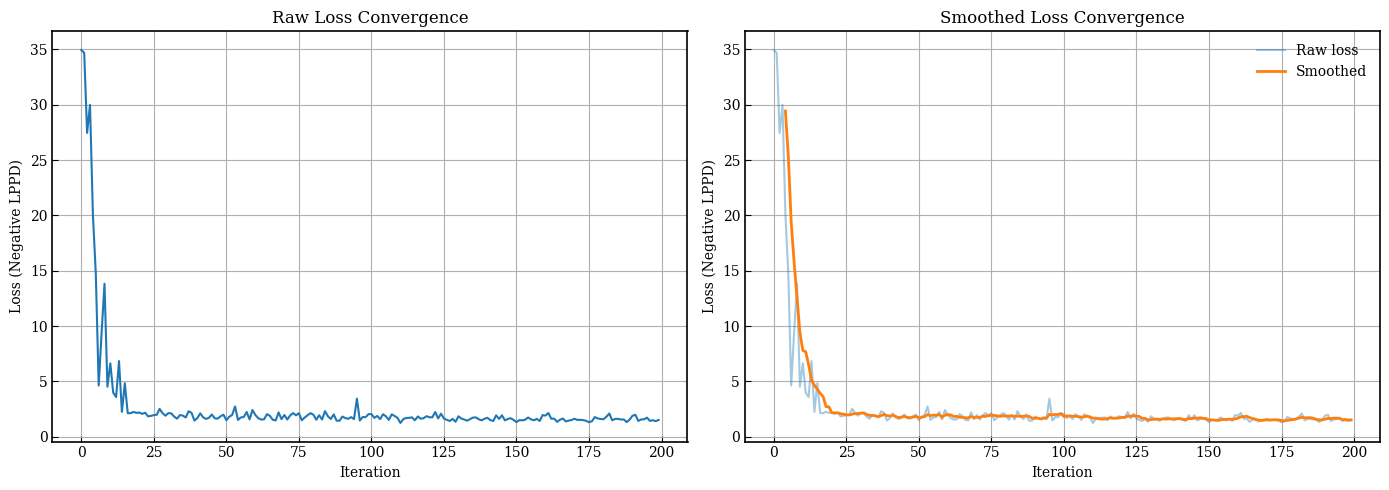

In [50]:
window = 5
smoothed_loss = np.convolve(loss_history, np.ones(window)/window, mode='valid')

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- LEFT: Raw loss ---
axes[0].plot(loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Loss (Negative LPPD)")
axes[0].set_title("Raw Loss Convergence")
axes[0].grid()

# --- RIGHT: Smoothed + raw ---
axes[1].plot(loss_history, alpha=0.4, label="Raw loss")
axes[1].plot(range(window-1, len(loss_history)),
             smoothed_loss,
             linewidth=2,
             label="Smoothed")

axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Loss (Negative LPPD)")
axes[1].set_title("Smoothed Loss Convergence")
axes[1].legend()
axes[1].grid()

# Layout
plt.tight_layout()

# Save combined figure
save_figure(fig, "lppd_convergence_combined")

plt.show()

Saved: lppd_convergence_decomposed_20260423_074549.png


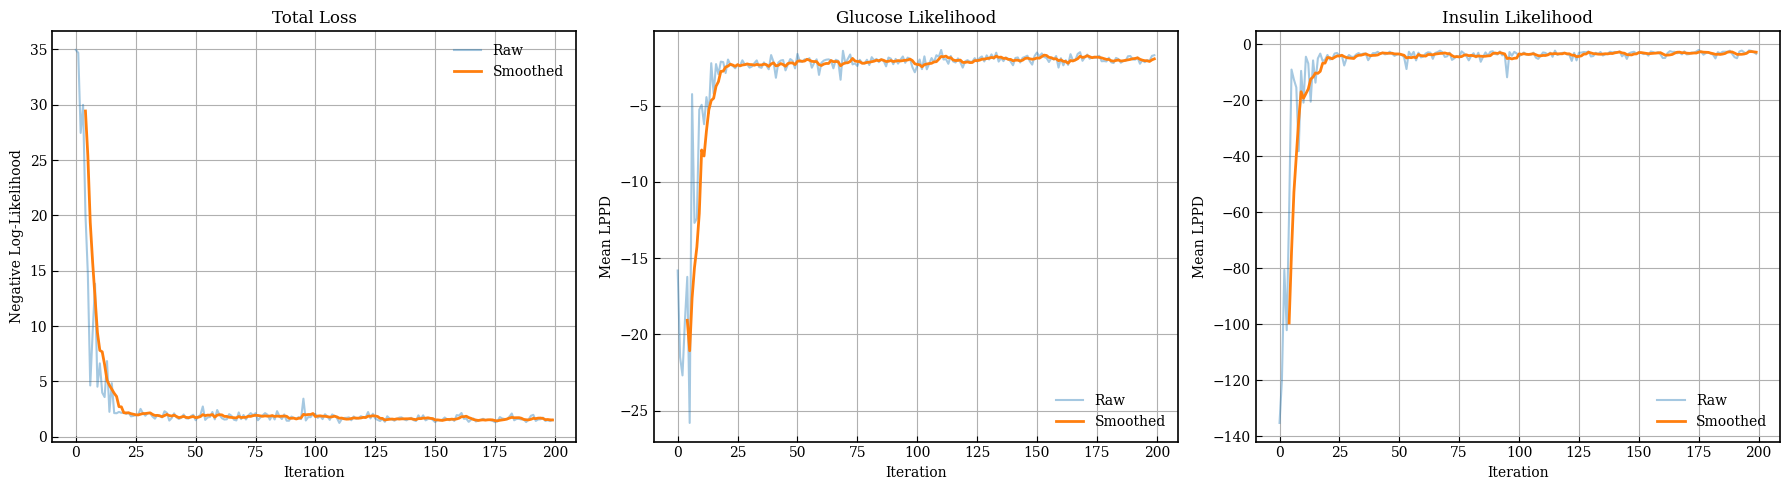

In [51]:
window = 5

# --- smoothing ---
smoothed_loss = np.convolve(loss_history, np.ones(window)/window, mode='valid')
smoothed_g = np.convolve(glucose_history, np.ones(window)/window, mode='valid')
smoothed_i = np.convolve(insulin_history, np.ones(window)/window, mode='valid')

# --- figure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TOTAL LOSS

axes[0].plot(loss_history, alpha=0.4, label="Raw")
axes[0].plot(range(window-1, len(loss_history)), smoothed_loss, linewidth=2, label="Smoothed")

axes[0].set_title("Total Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Negative Log-Likelihood")
axes[0].legend()
axes[0].grid()

# GLUCOSE

axes[1].plot(glucose_history, alpha=0.4, label="Raw")
axes[1].plot(range(window-1, len(glucose_history)), smoothed_g, linewidth=2, label="Smoothed")

axes[1].set_title("Glucose Likelihood")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Mean LPPD")
axes[1].legend()
axes[1].grid()

# INSULIN

axes[2].plot(insulin_history, alpha=0.4, label="Raw")
axes[2].plot(range(window-1, len(insulin_history)), smoothed_i, linewidth=2, label="Smoothed")

axes[2].set_title("Insulin Likelihood")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Mean LPPD")
axes[2].legend()
axes[2].grid()


plt.tight_layout()
save_figure(fig, "lppd_convergence_decomposed")
plt.show()

In [52]:
def softplus(x):
    return jnp.log(1 + jnp.exp(x))

mu_vals = optax_params["mus"]
sigma_raw = optax_params["sigmas"]
sigma_eff = softplus(sigma_raw)

print("mu:", mu_vals)
print("sigma_eff:", sigma_eff)

mu: [-4.801466  -4.491409  -1.7529632 -6.9077554 -4.246546  -6.9077554
 -4.396252 ]
sigma_eff: [1.9063272 0.9240456 2.7447865 0.6946483 3.7244418 0.6946483 2.3025548]


In [53]:
print(optax_params)
#optax_params["mus"] = 0.001*jnp.ones_like(optax_params["mus"])
for i in range(7,):
    print(np.mean(real_array[i][mask_array[i]]))
key, subkey = jax.random.split(key)
eps = jax.random.normal(subkey, shape=(N_samples, 7))
eps2_fixed = jax.random.normal(subkey, shape=(N_samples, 2))
scan_loss_fn(optax_params,real_array,insulin_array, mask_array,mvpa_data,calorie_data,eps_fixed,eps2_fixed,keys_fixed)

{'mus': Array([-4.801466 , -4.491409 , -1.7529632, -6.9077554, -4.246546 ,
       -6.9077554, -4.396252 ], dtype=float32), 'sigmas': Array([1.7454244e+00, 4.1835675e-01, 2.6783667e+00, 3.0000000e-03,
       3.7000194e+00, 3.0000000e-03, 2.1971910e+00], dtype=float32)}
5.022298
5.300318
5.7097826
6.3046703
6.5450516
6.2653713
6.2653713


(Array(1.3572109, dtype=float32),
 (Array([-2.2531736, -1.539704 , -1.6075718, -1.5908848, -1.7978911,
         -1.5963627], dtype=float32),
  Array([-1.8340657, -3.0743878, -2.1239   , -2.379602 , -2.910801 ,
         -2.4295993], dtype=float32),
  Array(-1.7309314, dtype=float32),
  Array(-2.458726, dtype=float32)))

## **Visualization of Model Trajectories and Data Comparison Across Age Bins**

Saved: Model_vs_Data_paper_style_labeled_20260423_074554.png


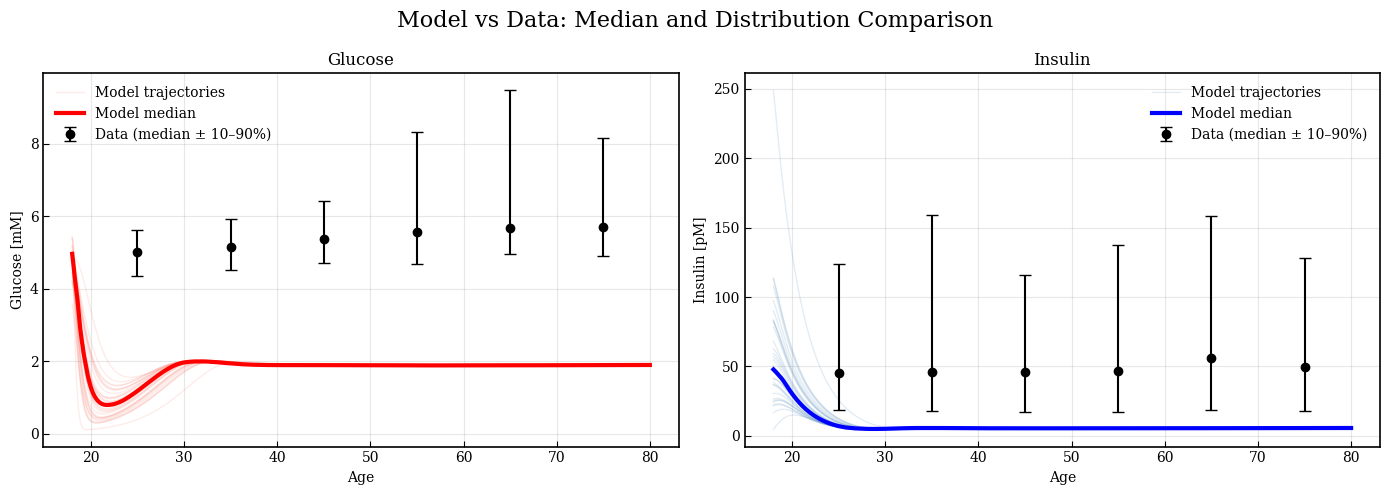

In [54]:
def plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    n_plot = min(30, states_np.shape[0])

    # =========================
    # GLUCOSE
    # =========================
    ax = axes[0]

    # --- trajectories (label only once!) ---
    for i in range(n_plot):
        ax.plot(
            t_span_np,
            states_np[i,:,0],
            color='salmon',
            alpha=0.15,
            linewidth=1,
            label='Model trajectories' if i == 0 else None
        )

    # --- median line ---
    p50_G = np.percentile(states_np[:,:,0], 50, axis=0)
    ax.plot(
        t_span_np,
        p50_G,
        color='red',
        linewidth=3,
        label='Model median'
    )

    # --- data ---
    data_x, data_y, err_low, err_high = [], [], [], []

    for age in age_list:
        vals = real_bins[age]

        p10 = np.percentile(vals, 10)
        p50 = np.percentile(vals, 50)
        p90 = np.percentile(vals, 90)

        data_x.append(age)
        data_y.append(p50)
        err_low.append(p50 - p10)
        err_high.append(p90 - p50)

    ax.errorbar(
        data_x,
        data_y,
        yerr=[err_low, err_high],
        fmt='o',
        color='black',
        capsize=4,
        label='Data (median ± 10–90%)'
    )

    ax.set_title("Glucose")
    ax.set_xlabel("Age")
    ax.set_ylabel("Glucose [mM]")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    # =========================
    # INSULIN
    # =========================
    ax = axes[1]

    model_I = states_np[:,:,2]

    # --- trajectories ---
    for i in range(n_plot):
        ax.plot(
            t_span_np,
            model_I[i],
            color='steelblue',
            alpha=0.15,
            linewidth=1,
            label='Model trajectories' if i == 0 else None
        )

    # --- median ---
    p50_I = np.percentile(model_I, 50, axis=0)
    ax.plot(
        t_span_np,
        p50_I,
        color='blue',
        linewidth=3,
        label='Model median'
    )

    # --- data ---
    data_x, data_y, err_low, err_high = [], [], [], []

    for age in age_list:
        vals = insulin_bins[age]

        p10 = np.percentile(vals, 10)
        p50 = np.percentile(vals, 50)
        p90 = np.percentile(vals, 90)

        data_x.append(age)
        data_y.append(p50)
        err_low.append(p50 - p10)
        err_high.append(p90 - p50)

    ax.errorbar(
        data_x,
        data_y,
        yerr=[err_low, err_high],
        fmt='o',
        color='black',
        capsize=4,
        label='Data (median ± 10–90%)'
    )

    ax.set_title("Insulin")
    ax.set_xlabel("Age")
    ax.set_ylabel("Insulin [pM]")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False)

    # =========================
    plt.suptitle("Model vs Data: Median and Distribution Comparison", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "Model_vs_Data_paper_style_labeled")
    plt.show()
plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins)

In [55]:
def plot_all_states_paper(states, t_span):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    labels = [
        "Glucose (G)",
        "Beta cells (B)",
        "Insulin (I)",
        "Sensitivity (S)",
        "Liver (L)"
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    n_plot = min(30, states_np.shape[0])

    for i in range(5):
        ax = axes[i]

        # -------------------------
        # faint trajectories
        # -------------------------
        for j in range(n_plot):
            ax.plot(
                t_span_np,
                states_np[j, :, i],
                alpha=0.15,
                linewidth=1
            )

        # -------------------------
        # percentiles
        # -------------------------
        p10 = np.percentile(states_np[:, :, i], 10, axis=0)
        p50 = np.percentile(states_np[:, :, i], 50, axis=0)
        p90 = np.percentile(states_np[:, :, i], 90, axis=0)

        # median line
        ax.plot(
            t_span_np,
            p50,
            linewidth=3,
            label="Median"
        )

        # uncertainty band
        ax.fill_between(
            t_span_np,
            p10,
            p90,
            alpha=0.2,
            label="10–90%"
        )

        # -------------------------
        # labels
        # -------------------------
        ax.set_title(labels[i])
        ax.set_xlabel("Age")
        ax.set_ylabel("Value")
        ax.grid(alpha=0.3)

        ax.legend()

    # remove empty subplot
    fig.delaxes(axes[5])

    plt.suptitle("Simulated Physiological Trajectories", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "Simulated_Physiological_Trajectories_paper_style")
    plt.show()

Saved: Simulated_Physiological_Trajectories_paper_style_20260423_074558.png


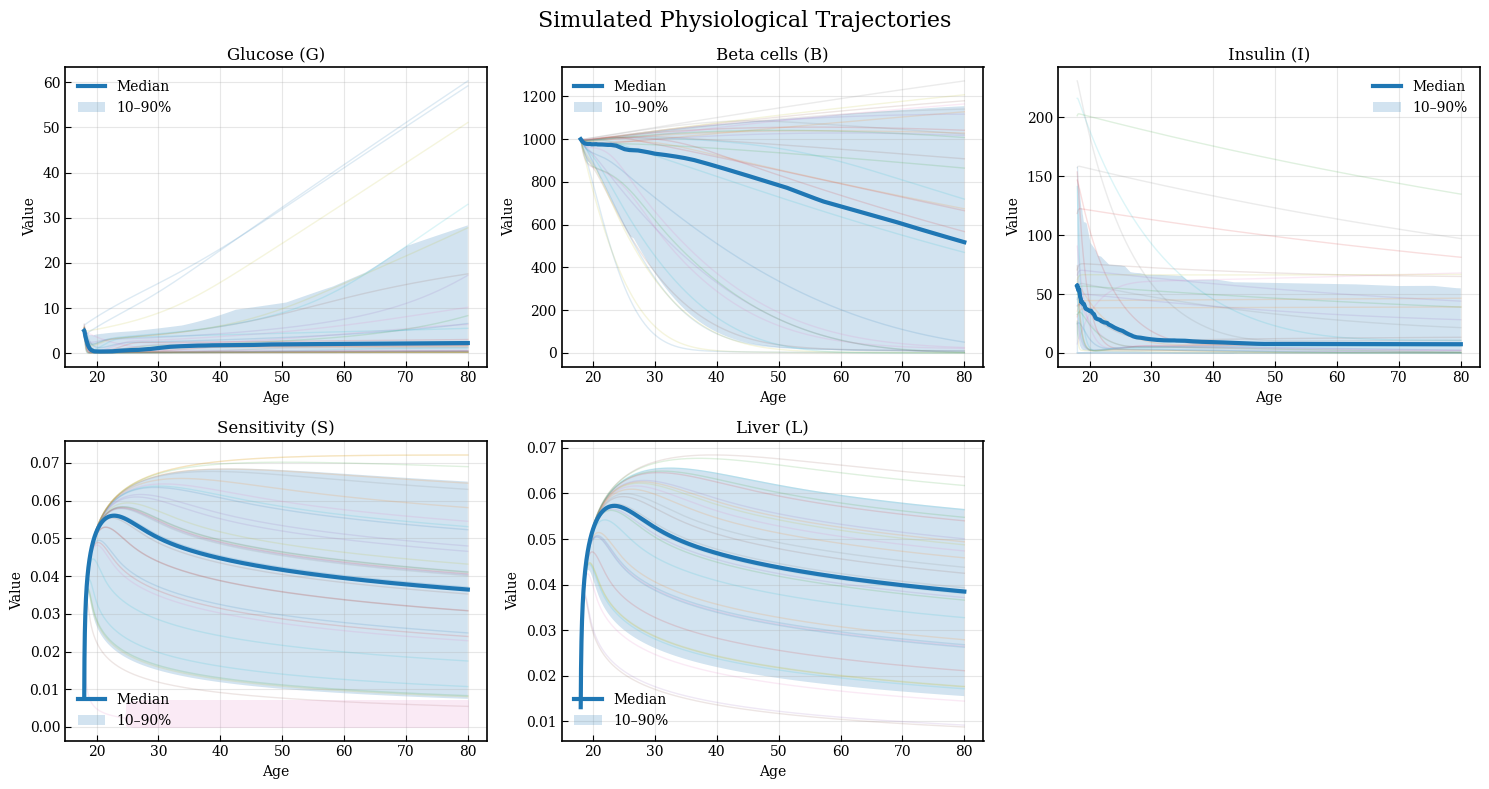

In [56]:
t_span, states = debug_simulation(optax_params, mvpa_data, calorie_data, eps_fixed,eps2_fixed,keys_fixed)

plot_all_states_paper(states, t_span)

Saved: Model_vs_Data_paper_style_labeled_20260423_074605.png


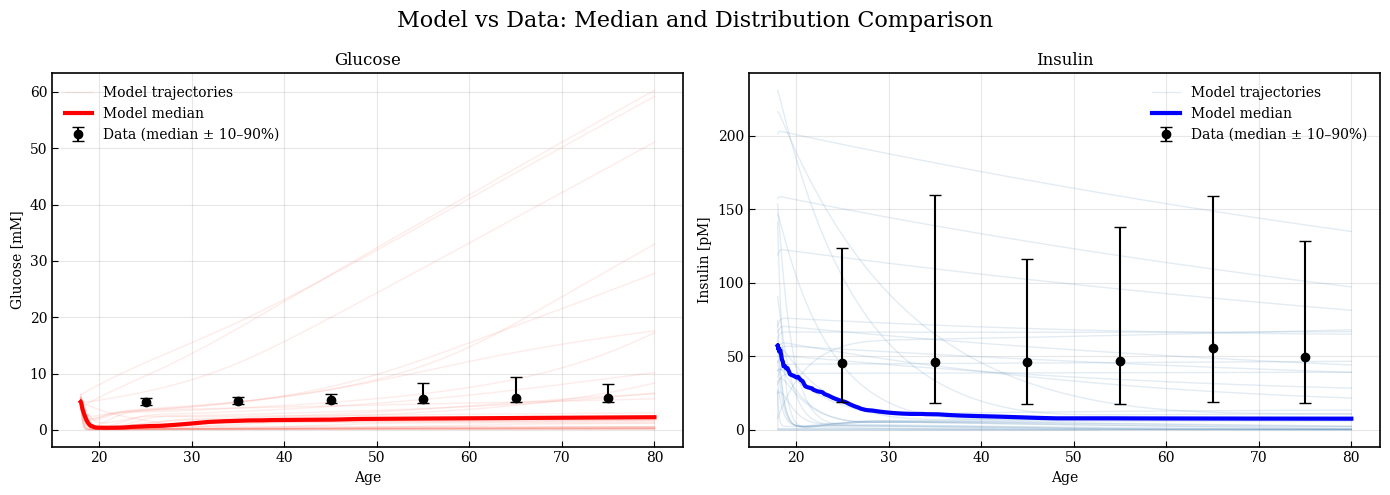

NameError: name 'plot_all_states' is not defined

In [57]:
# ============================================
# DEBUG VISUALIZATION — BEHAVIOR EXPERIMENT
# ============================================

t_span_fixed, states_const = debug_simulation_fixed(
    optax_params,
    eps_fixed,
    eps2_fixed,
    F_const,
    Y_const
)

t_span_fixed, states_dyn = debug_simulation_fixed(
    optax_params,
    eps_fixed,
    eps2_fixed,
    F_dynamic,
    Y_dynamic
)

# --- Plot constant behavior ---
plot_glucose_insulin(
    states_const,
    t_span_fixed,
    age_list,
    real_bins,
    insulin_bins
)

plot_all_states(states_const, t_span_fixed)


# --- Plot dynamic behavior ---
plot_glucose_insulin(
    states_dyn,
    t_span_fixed,
    age_list,
    real_bins,
    insulin_bins
)

plot_all_states(states_dyn, t_span_fixed)

In [ ]:
def plot_glucose_insulin(states, t_span, age_list, real_bins, insulin_bins, log_plot=True):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # =========================================================
    # GLUCOSE
    # =========================================================
    ax = axes[0]

    G_model = states_np[:, :, 0]

    if log_plot:
        G_model = np.log(G_model + 1e-6)

    # --- percentiles ---
    p10 = np.percentile(G_model, 10, axis=0)
    p50 = np.percentile(G_model, 50, axis=0)
    p90 = np.percentile(G_model, 90, axis=0)

    ax.plot(t_span_np, p50, color='black', linewidth=2, label='Model median')
    ax.fill_between(t_span_np, p10, p90, alpha=0.3, label='Model 10–90%')

    # --- data percentiles ---
    data_p10 = []
    data_p50 = []
    data_p90 = []

    for age in age_list:
        vals = np.array(real_bins[age])

        if log_plot:
            vals = np.log(vals + 1e-6)

        data_p10.append(np.percentile(vals, 10))
        data_p50.append(np.percentile(vals, 50))
        data_p90.append(np.percentile(vals, 90))

    ax.errorbar(age_list, data_p50,
                yerr=[np.array(data_p50)-np.array(data_p10),
                      np.array(data_p90)-np.array(data_p50)],
                fmt='o', color='red', label='Data (10–90%)')

    ax.set_title("Glucose vs Age")
    ax.set_xlabel("Age")
    ax.set_ylabel("log(Glucose)" if log_plot else "Glucose")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # =========================================================
    # INSULIN
    # =========================================================
    ax = axes[1]

    I_model = states_np[:, :, 2]

    if log_plot:
        I_model = np.log(I_model + 1e-6)

    # --- percentiles ---
    p10 = np.percentile(I_model, 10, axis=0)
    p50 = np.percentile(I_model, 50, axis=0)
    p90 = np.percentile(I_model, 90, axis=0)

    ax.plot(t_span_np, p50, color='black', linewidth=2, label='Model median')
    ax.fill_between(t_span_np, p10, p90, alpha=0.3, label='Model 10–90%')

    # --- data percentiles ---
    data_p10 = []
    data_p50 = []
    data_p90 = []

    for age in age_list:
        vals = np.array(insulin_bins[age])

        if log_plot:
            vals = np.log(vals + 1e-6)

        data_p10.append(np.percentile(vals, 10))
        data_p50.append(np.percentile(vals, 50))
        data_p90.append(np.percentile(vals, 90))

    ax.errorbar(age_list, data_p50,
                yerr=[np.array(data_p50)-np.array(data_p10),
                      np.array(data_p90)-np.array(data_p50)],
                fmt='o', color='red', label='Data (10–90%)')

    ax.set_title("Insulin vs Age")
    ax.set_xlabel("Age")
    ax.set_ylabel("log(Insulin)" if log_plot else "Insulin")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # =========================================================
    plt.suptitle("Model vs Data (Predictive Intervals)", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "model_vs_data_percentiles")
    plt.show()


def plot_all_states(states, t_span):

  states_np = np.array(states)
  t_span_np = np.array(t_span)

  labels = ["Glucose (G)", "Beta cells (B)", "Insulin (I)", "Sensitivity (S)", "Liver (L)"]

  fig, axes = plt.subplots(2, 3, figsize=(14, 8))
  axes = axes.flatten()

  for i in range(5):
      ax = axes[i]

      X = states_np[:, :, i]

      p10 = np.percentile(X, 10, axis=0)
      p50 = np.percentile(X, 50, axis=0)
      p90 = np.percentile(X, 90, axis=0)

      ax.plot(t_span_np, p50, linewidth=2, label="Median")
      ax.fill_between(t_span_np, p10, p90, alpha=0.3, label="10–90%")

      ax.set_title(labels[i])
      ax.set_xlabel("Age")
      ax.set_ylabel("Value")
      ax.grid(True, alpha=0.3)

  fig.delaxes(axes[5])

  plt.suptitle("Simulated Physiological Trajectories (Predictive Intervals)", fontsize=16)
  plt.tight_layout()
  save_figure(fig, "Simulated_Physiological_Trajectories_percentiles")
  plt.show()

In [ ]:
def compare_behavior(states_const, states_dyn, t_span):

    t = np.array(t_span)

    G_const = np.array(states_const[:,:,0]).mean(axis=0)
    G_dyn   = np.array(states_dyn[:,:,0]).mean(axis=0)

    I_const = np.log(np.array(states_const[:,:,2]) + 1e-6).mean(axis=0)
    I_dyn   = np.log(np.array(states_dyn[:,:,2]) + 1e-6).mean(axis=0)

    fig, axes = plt.subplots(1,2, figsize=(12,5))

    # Glucose
    axes[0].plot(t, G_const, label="Constant", linewidth=2)
    axes[0].plot(t, G_dyn, label="Dynamic", linewidth=2)
    axes[0].set_title("Glucose comparison")
    axes[0].set_xlabel("Age")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Insulin
    axes[1].plot(t, I_const, label="Constant", linewidth=2)
    axes[1].plot(t, I_dyn, label="Dynamic", linewidth=2)
    axes[1].set_title("Insulin (log) comparison")
    axes[1].set_xlabel("Age")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# --- simulate ---
t_span, states = debug_simulation(
    optax_params,
    mvpa_data,
    calorie_data,
    eps_fixed,
    eps2_fixed,
    keys_fixed
)

# --- main comparison plot ---
plot_glucose_insulin(
    states,
    t_span,
    age_list,
    real_bins,
    insulin_bins,
    log_plot=True
)

# --- full state visualization ---
plot_all_states(states, t_span)

In [ ]:
def plot_glucose_insulin_fixed(states, t_span, age_list, real_bins, insulin_bins, log_plot=True):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # =========================================================
    # GLUCOSE
    # =========================================================
    ax = axes[0]

    G_model = states_np[:, :, 0]

    if log_plot:
        G_model = np.log(G_model + 1e-6)

    p10 = np.percentile(G_model, 10, axis=0)
    p50 = np.percentile(G_model, 50, axis=0)
    p90 = np.percentile(G_model, 90, axis=0)

    ax.plot(t_span_np, p50, linewidth=2, label='Model median (fixed behavior)')
    ax.fill_between(t_span_np, p10, p90, alpha=0.3, label='Model 10–90%')

    # data
    data_p10, data_p50, data_p90 = [], [], []

    for age in age_list:
        vals = np.array(real_bins[age])
        if log_plot:
            vals = np.log(vals + 1e-6)

        data_p10.append(np.percentile(vals, 10))
        data_p50.append(np.percentile(vals, 50))
        data_p90.append(np.percentile(vals, 90))

    ax.errorbar(age_list, data_p50,
                yerr=[np.array(data_p50)-np.array(data_p10),
                      np.array(data_p90)-np.array(data_p50)],
                fmt='o', label='Data (10–90%)')

    ax.set_title("Glucose vs Age (Fixed Behavior)")
    ax.set_xlabel("Age")
    ax.set_ylabel("log(Glucose)" if log_plot else "Glucose")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # =========================================================
    # INSULIN
    # =========================================================
    ax = axes[1]

    I_model = states_np[:, :, 2]

    if log_plot:
        I_model = np.log(I_model + 1e-6)

    p10 = np.percentile(I_model, 10, axis=0)
    p50 = np.percentile(I_model, 50, axis=0)
    p90 = np.percentile(I_model, 90, axis=0)

    ax.plot(t_span_np, p50, linewidth=2, label='Model median (fixed behavior)')
    ax.fill_between(t_span_np, p10, p90, alpha=0.3, label='Model 10–90%')

    data_p10, data_p50, data_p90 = [], [], []

    for age in age_list:
        vals = np.array(insulin_bins[age])
        if log_plot:
            vals = np.log(vals + 1e-6)

        data_p10.append(np.percentile(vals, 10))
        data_p50.append(np.percentile(vals, 50))
        data_p90.append(np.percentile(vals, 90))

    ax.errorbar(age_list, data_p50,
                yerr=[np.array(data_p50)-np.array(data_p10),
                      np.array(data_p90)-np.array(data_p50)],
                fmt='o', label='Data (10–90%)')

    ax.set_title("Insulin vs Age (Fixed Behavior)")
    ax.set_xlabel("Age")
    ax.set_ylabel("log(Insulin)" if log_plot else "Insulin")
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.suptitle("Model vs Data (Fixed Behavior Inputs)", fontsize=16)
    plt.tight_layout()
    save_figure(fig, "model_vs_data_fixed_behavior")
    plt.show()

In [ ]:
# --- simulate (fixed behavior) ---
t_span, states = debug_simulation_fixed(
    optax_params,
    eps_fixed,
    eps2_fixed,
    F_all,
    Y_all
)

# --- plot ---
plot_glucose_insulin_fixed(
    states,
    t_span,
    age_list,
    real_bins,
    insulin_bins,
    log_plot=True
)

In [ ]:
def plot_distribution_comparison(states, t_span, age_list, real_bins, insulin_bins, age_target):

    states_np = np.array(states)
    t_span_np = np.array(t_span)

    # find closest index to chosen age
    idx = np.argmin(np.abs(t_span_np - age_target))

    # get data
    real_g = real_bins[age_target]
    sim_g  = states_np[:, idx, 0]

    real_i = np.log(insulin_bins[age_target] + 1e-6)
    sim_i  = np.log(states_np[:, idx, 2] + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- GLUCOSE ---
    axes[0].hist(real_g, bins=30, alpha=0.5, density=True, label="Observed")
    axes[0].hist(sim_g,  bins=30, alpha=0.5, density=True, label="Simulated")

    axes[0].set_title(f"Glucose Distribution at Age {age_target}")
    axes[0].set_xlabel("Glucose")
    axes[0].set_ylabel("Density")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --- INSULIN (LOG) ---
    axes[1].hist(real_i, bins=30, alpha=0.5, density=True, label="Observed")
    axes[1].hist(sim_i,  bins=30, alpha=0.5, density=True, label="Simulated")

    axes[1].set_title(f"log(Insulin) Distribution at Age {age_target}")
    axes[1].set_xlabel("log(Insulin)")
    axes[1].set_ylabel("Density")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    save_figure(fig, f"distribution_comparison_age_{age_target}")
    plt.show()

plot_distribution_comparison(
    states,
    t_span,
    age_list,
    real_bins,
    insulin_bins,
    age_target=45   #
)

In [ ]:
# ============================================
# 4.7 — BEHAVIOR: PERCENTILE TRAJECTORIES
# ============================================

t_span = jnp.linspace(18, 80, 1000)
G_const = states_constant[:, :, 0]
G_dyn   = states_dynamic[:, :, 0]

# Median
median_const = jnp.percentile(G_const, 50, axis=0)
median_dyn   = jnp.percentile(G_dyn, 50, axis=0)

# 10–90 bands
p10_const = jnp.percentile(G_const, 10, axis=0)
p90_const = jnp.percentile(G_const, 90, axis=0)

p10_dyn = jnp.percentile(G_dyn, 10, axis=0)
p90_dyn = jnp.percentile(G_dyn, 90, axis=0)

plt.figure(figsize=(10,6))

plt.plot(t_span, median_const, label="Constant", linewidth=3)
plt.fill_between(t_span, p10_const, p90_const, alpha=0.2)

plt.plot(t_span, median_dyn, label="Dynamic", linewidth=3)
plt.fill_between(t_span, p10_dyn, p90_dyn, alpha=0.2)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Effect of Behavior on Glucose Trajectories (10–90%)")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================
# 4.7 — BEHAVIOR: DIFFERENCE PLOT
# ============================================

diff_all = G_dyn - G_const

diff_mean = diff_all.mean(axis=0)
p10_diff  = jnp.percentile(diff_all, 10, axis=0)
p90_diff  = jnp.percentile(diff_all, 90, axis=0)

plt.figure(figsize=(10,6))

plt.plot(t_span, diff_mean, color='black', linewidth=3, label="Mean difference")
plt.fill_between(t_span, p10_diff, p90_diff, alpha=0.2)

plt.axhline(0, linestyle='--', color='gray')

plt.xlabel("Age")
plt.ylabel("Δ Glucose (Dynamic - Constant)")
plt.title("Impact of Time-Varying Behavior")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================
# 4.7 — BEHAVIOR: DISTRIBUTION SNAPSHOTS
# ============================================

ages_to_check = [30, 50, 70]

plt.figure(figsize=(12,4))

for i, age in enumerate(ages_to_check):
    idx = int(jnp.argmin(jnp.abs(t_span - age)))

    plt.subplot(1,3,i+1)

    plt.hist(G_const[:, idx], bins=30, density=True, alpha=0.5, label="Const")
    plt.hist(G_dyn[:, idx], bins=30, density=True, alpha=0.5, label="Dynamic")

    plt.title(f"Age {age}")
    plt.xlabel("Glucose")
    plt.ylabel("Density")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 4.8 — INITIALIZATION SENSITIVITY
# ============================================

G_emp = states_empirical[:, :, 0]
G_dist = states_distribution[:, :, 0]

median_emp = jnp.percentile(G_emp, 50, axis=0)
median_dist = jnp.percentile(G_dist, 50, axis=0)

p10_emp = jnp.percentile(G_emp, 10, axis=0)
p90_emp = jnp.percentile(G_emp, 90, axis=0)

p10_dist = jnp.percentile(G_dist, 10, axis=0)
p90_dist = jnp.percentile(G_dist, 90, axis=0)

plt.figure(figsize=(10,6))

plt.plot(t_span, median_emp, label="Empirical", linewidth=3)
plt.fill_between(t_span, p10_emp, p90_emp, alpha=0.2)

plt.plot(t_span, median_dist, label="Distribution", linewidth=3)
plt.fill_between(t_span, p10_dist, p90_dist, alpha=0.2)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Sensitivity to Initial Conditions")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ============================================
# 4.9 — PARAMETER SENSITIVITY (k_OI)
# ============================================

plt.figure(figsize=(10,6))

for s, states in results_kI.items():
    G = states[:, :, 0]
    median = jnp.percentile(G, 50, axis=0)

    plt.plot(t_span, median, label=f"Scale {s}", linewidth=2)

plt.xlabel("Age")
plt.ylabel("Glucose")
plt.title("Sensitivity to Insulin Decay Parameter (k_OI)")

plt.legend()
plt.grid(alpha=0.3)
plt.show()